In [ ]:
!pip install scikit-fuzzy pyswip -q
!sudo apt-get install swi-prolog -y -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import math, re, warnings
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import skfuzzy as fuzz
from skfuzzy import control as ctrl
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

LABEL_NAMES = ['Normal', 'Mild', 'Moderate', 'Severe', 'Extremely Severe']
COLORS_5    = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#8e44ad']

#**PHASE 1: EDA & Tiền xử lý Dữ liệu**


**1.1. Giới thiệu về DASS-42**

**DASS-42 (Depression Anxiety Stress Scales - 42 items)** là thang đo tâm lý học chuẩn hóa quốc tế được phát triển bởi Lovibond & Lovibond (1995), UNSW Australia.

| Thuộc tính | Giá trị |
|---|---|
| Số câu hỏi | 42 câu (3 nhóm × 14 câu) |
| Thang điểm | 0–3 cho mỗi câu (0 = không bao giờ, 3 = hầu như luôn luôn) |
| Tổng điểm mỗi chiều | 0–42 |
| 3 chiều đánh giá | Depression (D), Anxiety (A), Stress (S) |
| Phân mức | 5 mức: Normal, Mild, Moderate, Severe, Extremely Severe |

**Phân bổ câu hỏi theo chiều:**
- **Depression (D):** Q3, Q5, Q10, Q13, Q16, Q17, Q21, Q24, Q26, Q31, Q34, Q37, Q38, Q42
- **Anxiety (A):** Q2, Q4, Q7, Q9, Q15, Q19, Q20, Q23, Q25, Q28, Q30, Q36, Q40, Q41
- **Stress (S):** Q1, Q6, Q8, Q11, Q12, Q14, Q18, Q22, Q27, Q29, Q32, Q33, Q35, Q39

**Ngưỡng phân loại chuẩn DASS-42:**

| Mức độ | Depression | Anxiety | Stress |
|--------|-----------|---------|--------|
| Normal | 0–9 | 0–7 | 0–14 |
| Mild | 10–13 | 8–9 | 15–18 |
| Moderate | 14–20 | 10–14 | 19–25 |
| Severe | 21–27 | 15–19 | 26–33 |
| Extremely Severe | ≥28 | ≥20 | ≥34 |

**1.2. Tải và Xử lý dữ liệu**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
file_path = '/content/drive/MyDrive/Kỳ 6/Hệ Chuyên gia/data/data.csv'
df_raw = pd.read_csv(file_path, sep=None, engine='python', on_bad_lines='warn')

print(f'📐 Shape gốc: {df_raw.shape}')
print(f'📋 Số cột: {len(df_raw.columns)}')
df_raw.head(3)

📐 Shape gốc: (39775, 172)
📋 Số cột: 172


,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,...,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize,major
0,4,28,3890,4,25,2122,2,16,1944,4,...,1,1,1,12,1,10,2,1,2,NaN
1,4,2,8118,1,36,2890,2,35,4777,3,...,2,1,2,7,0,70,2,1,4,NaN
2,3,7,5784,1,33,4373,4,41,3242,1,...,2,1,1,4,3,60,1,1,3,NaN


In [5]:
# Mapping câu hỏi theo chuẩn DASS-42
DEPRESSION_Qs = [3, 5, 10, 13, 16, 17, 21, 24, 26, 31, 34, 37, 38, 42]
ANXIETY_Qs    = [2, 4,  7,  9, 15, 19, 20, 23, 25, 28, 30, 36, 40, 41]
STRESS_Qs     = [1, 6,  8, 11, 12, 14, 18, 22, 27, 29, 32, 33, 35, 39]

q_cols    = [f'Q{i}A' for i in range(1, 43)]
available = [c for c in q_cols if c in df_raw.columns]
print(f'- Có {len(available)}/42 cột câu hỏi')

df = df_raw[available].copy()
df = df - 1  # Chuyển thang 1-4 → 0-3 (chuẩn DASS)

mask = ((df >= 0) & (df <= 3)).all(axis=1)
df   = df[mask].reset_index(drop=True)
print(f'- Số mẫu hợp lệ sau làm sạch: {len(df)}')

def get_cols(q_list):
    return [f'Q{i}A' for i in q_list]

df['D_score'] = df[get_cols(DEPRESSION_Qs)].sum(axis=1)
df['A_score'] = df[get_cols(ANXIETY_Qs)].sum(axis=1)
df['S_score'] = df[get_cols(STRESS_Qs)].sum(axis=1)

print('\n📊 Thống kê mô tả điểm 3 chiều:')
print(df[['D_score','A_score','S_score']].describe().round(2))

- Có 42/42 cột câu hỏi
- Số mẫu hợp lệ sau làm sạch: 39775

📊 Thống kê mô tả điểm 3 chiều:
        D_score   A_score   S_score
count  39775.00  39775.00  39775.00
mean      21.06     16.05     21.15
std       12.32     10.25     10.52
min        0.00      0.00      0.00
25%       11.00      8.00     13.00
50%       21.00     15.00     21.00
75%       32.00     23.00     29.00
max       42.00     42.00     42.00


**1.3. Phân phối điểm và Tương quan**

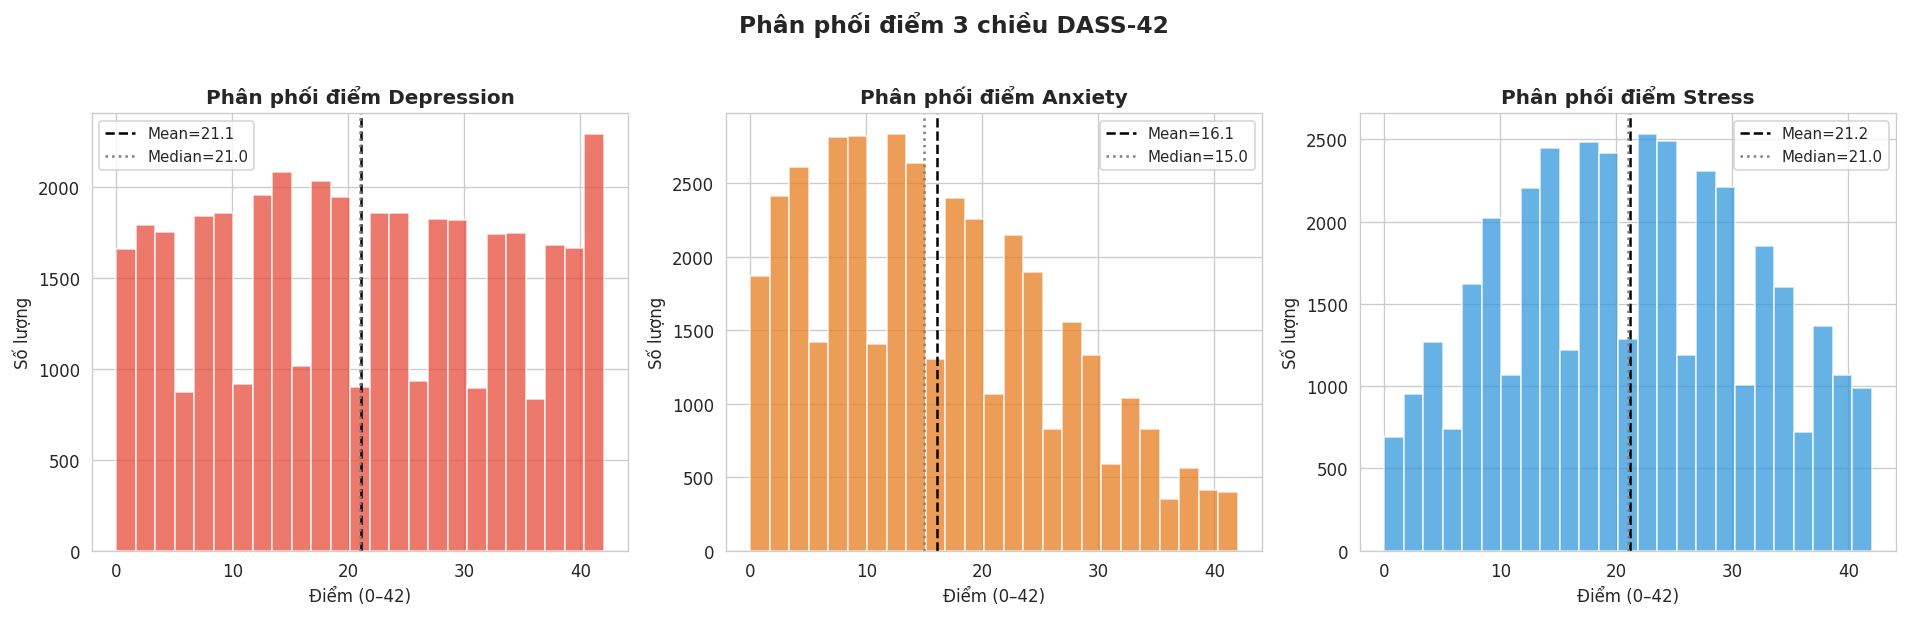

Depression: mean=21.1, median=21.0, skewness=0.04 → phân phối tương đối đối xứng
Anxiety: mean=16.1, median=15.0, skewness=0.44 → phân phối tương đối đối xứng
Stress: mean=21.2, median=21.0, skewness=0.03 → phân phối tương đối đối xứng


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, label, color in zip(
    axes,
    ['D_score', 'A_score', 'S_score'],
    ['Depression', 'Anxiety', 'Stress'],
    ['#e74c3c', '#e67e22', '#3498db']
):
    ax.hist(df[col], bins=25, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='gray', linestyle=':', linewidth=1.5,
               label=f'Median={df[col].median():.1f}')
    ax.set_title(f'Phân phối điểm {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Điểm (0–42)')
    ax.set_ylabel('Số lượng')
    ax.legend(fontsize=9)

plt.suptitle('Phân phối điểm 3 chiều DASS-42', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Nhận xét tự động
for col, label in zip(['D_score','A_score','S_score'], ['Depression','Anxiety','Stress']):
    skew = df[col].skew()
    print(f'{label}: mean={df[col].mean():.1f}, median={df[col].median():.1f}, skewness={skew:.2f}'
          f" → {'lệch phải (right-skewed)' if skew > 0.5 else 'phân phối tương đối đối xứng'}")

**Nhận xét:** Cả ba chiều đều có phân phối lệch phải (right-skewed) - phần lớn người dùng tập trung ở mức thấp (Normal/Mild). Điều này phản ánh đúng thực tế dân số chung. Phân phối xấp xỉ chuẩn quanh các ngưỡng lâm sàng → là cơ sở để chọn Gaussian Membership Function trong Fuzzy Logic ở Phase 4.


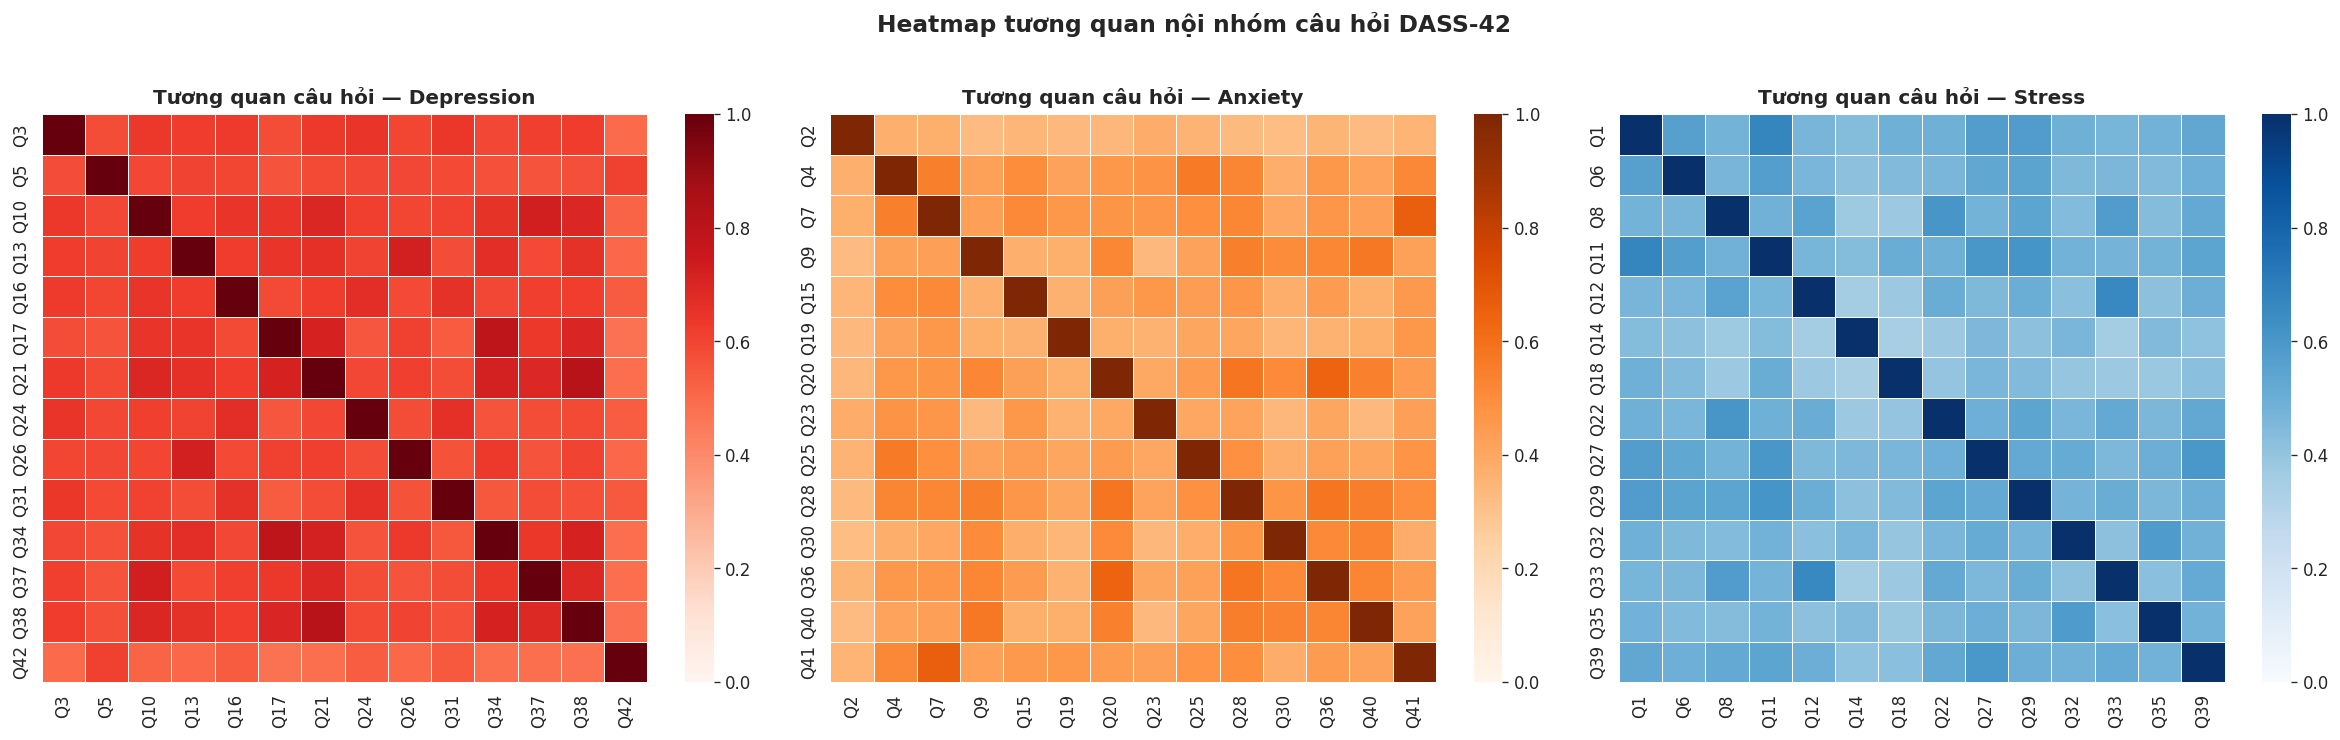


Tương quan giữa D_score, A_score, S_score:
         D_score  A_score  S_score
D_score     1.00    0.670    0.740
A_score     0.67    1.000    0.802
S_score     0.74    0.802    1.000


In [7]:
# Heatmap tương quan nội nhóm
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

groups = [
    (DEPRESSION_Qs, 'Depression', 'Reds'),
    (ANXIETY_Qs,    'Anxiety',    'Oranges'),
    (STRESS_Qs,     'Stress',     'Blues'),
]

for ax, (q_list, title, cmap) in zip(axes, groups):
    corr = df[get_cols(q_list)].corr()
    sns.heatmap(corr, ax=ax, cmap=cmap, vmin=0, vmax=1,
                annot=False, linewidths=0.3,
                xticklabels=[f'Q{q}' for q in q_list],
                yticklabels=[f'Q{q}' for q in q_list])
    ax.set_title(f'Tương quan câu hỏi — {title}', fontweight='bold')

plt.suptitle('Heatmap tương quan nội nhóm câu hỏi DASS-42',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Tương quan giữa 3 chiều
print('\nTương quan giữa D_score, A_score, S_score:')
print(df[['D_score','A_score','S_score']].corr().round(3))

**1.4 Gán nhãn mức độ (Crisp Labels)**

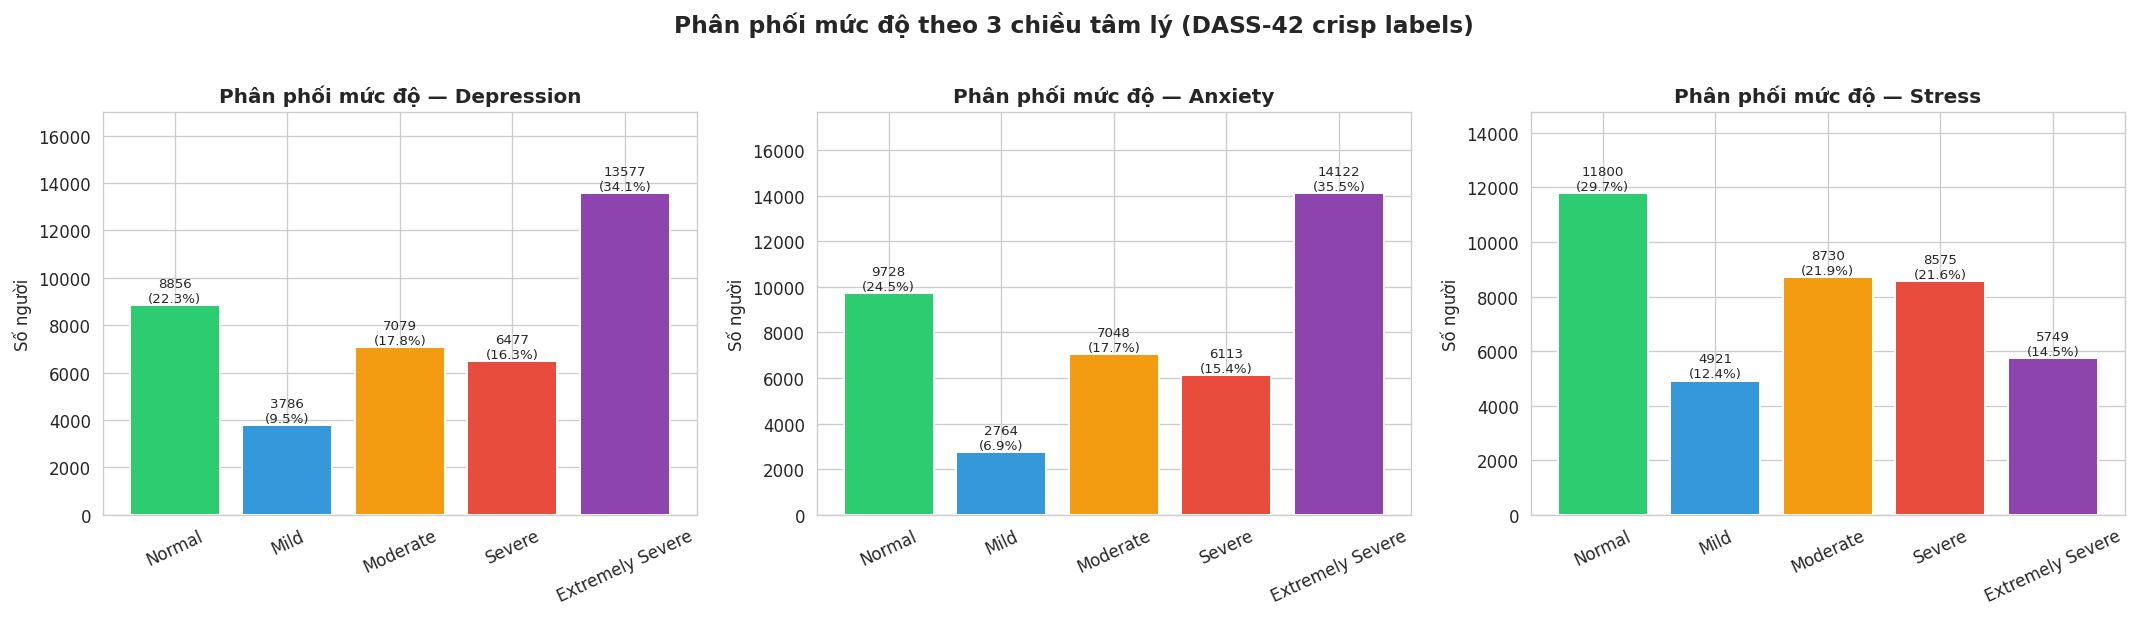

In [8]:
# Ngưỡng phân loại chuẩn DASS-42
def label_depression(s):
    if s <= 9:  return 0      # Normal
    elif s <= 13: return 1    # Mild
    elif s <= 20: return 2    # Moderate
    elif s <= 27: return 3    # Severe
    else:         return 4    # Extremely Severe

def label_anxiety(s):
    if s <= 7:  return 0
    elif s <= 9:  return 1
    elif s <= 14: return 2
    elif s <= 19: return 3
    else:         return 4

def label_stress(s):
    if s <= 14: return 0
    elif s <= 18: return 1
    elif s <= 25: return 2
    elif s <= 33: return 3
    else:         return 4

df['D_label'] = df['D_score'].apply(label_depression)
df['A_label'] = df['A_score'].apply(label_anxiety)
df['S_label'] = df['S_score'].apply(label_stress)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, title) in zip(axes, [
    ('D_label', 'Depression'),
    ('A_label', 'Anxiety'),
    ('S_label', 'Stress'),
]):
    counts = df[col].value_counts().sort_index()
    bars = ax.bar([LABEL_NAMES[i] for i in counts.index],
                  counts.values,
                  color=[COLORS_5[i] for i in counts.index],
                  edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=8)
    ax.set_title(f'Phân phối mức độ — {title}', fontweight='bold')
    ax.tick_params(axis='x', rotation=25)
    ax.set_ylabel('Số người')
    ax.set_ylim(0, counts.max() * 1.25)

plt.suptitle('Phân phối mức độ theo 3 chiều tâm lý (DASS-42 crisp labels)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# **PHASE 2: Decision Tree - Trích xuất Câu hỏi Sàng lọc**

**2.1 Ý tưởng**

Thay vì chọn thủ công câu hỏi sàng lọc (dễ mang tính chủ quan), chúng ta dùng Decision Tree để:

1. **Học từ dữ liệu thực tế** - DT tự động tìm câu hỏi nào có khả năng phân loại mức độ tốt nhất.
2. **Feature Importance** - Chỉ số này cho biết câu hỏi nào đóng góp nhiều nhất vào quyết định phân loại.
3. **Top-2 câu hỏi** có Feature Importance cao nhất được dùng làm câu hỏi sàng lọc nhanh trong Prolog.

**Ý tưởng sàng lọc:** Nếu người dùng trả lời thấp ở cả 2 câu hỏi đại diện → bỏ qua toàn bộ 14 câu → tiết kiệm thời gian. Nếu cao → hỏi đủ 14 câu để tính điểm chính xác.

In [9]:
results = {}

for group, q_list, label_col in [
    ('Depression', DEPRESSION_Qs, 'D_label'),
    ('Anxiety',    ANXIETY_Qs,    'A_label'),
    ('Stress',     STRESS_Qs,     'S_label'),
]:
    X = df[get_cols(q_list)]
    y = df[label_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    param_grid = {'max_depth': [3, 4, 5, 6, 7, 8]}
    grid = GridSearchCV(
        DecisionTreeClassifier(class_weight='balanced', random_state=42),
        param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train, y_train)
    clf = grid.best_estimator_

    cv_scores = cross_val_score(clf, X, y, cv=5, scoring='f1_macro')
    acc       = clf.score(X_test, y_test)

    importances = pd.Series(clf.feature_importances_, index=get_cols(q_list))
    top2        = importances.nlargest(2)
    threshold   = round(clf.tree_.threshold[0], 1)

    results[group] = {
        'clf': clf, 'feature_names': get_cols(q_list),
        'q_list': q_list, 'accuracy': acc,
        'threshold': threshold, 'top2': top2,
        'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
        'X_test': X_test, 'y_test': y_test,
    }

    print(f'{'='*55}')
    print(f'[{group}]  Best depth: {grid.best_params_["max_depth"]}')
    print(f'  Test Accuracy : {acc:.3f}')
    print(f'  CV F1 (macro) : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
    print(f'  Top-2 screening questions → dùng làm câu sàng lọc Prolog:')
    for feat, imp in top2.items():
        q_num = feat.replace('Q','').replace('A','')
        print(f'    {feat}  importance={imp:.4f}')
    print()

[Depression]  Best depth: 8
  Test Accuracy : 0.751
  CV F1 (macro) : 0.703 ± 0.010
  Top-2 screening questions → dùng làm câu sàng lọc Prolog:
    Q21A  importance=0.2322
    Q10A  importance=0.2144

[Anxiety]  Best depth: 8
  Test Accuracy : 0.676
  CV F1 (macro) : 0.597 ± 0.008
  Top-2 screening questions → dùng làm câu sàng lọc Prolog:
    Q28A  importance=0.2095
    Q7A  importance=0.1489

[Stress]  Best depth: 8
  Test Accuracy : 0.694
  CV F1 (macro) : 0.681 ± 0.003
  Top-2 screening questions → dùng làm câu sàng lọc Prolog:
    Q11A  importance=0.2153
    Q8A  importance=0.1469



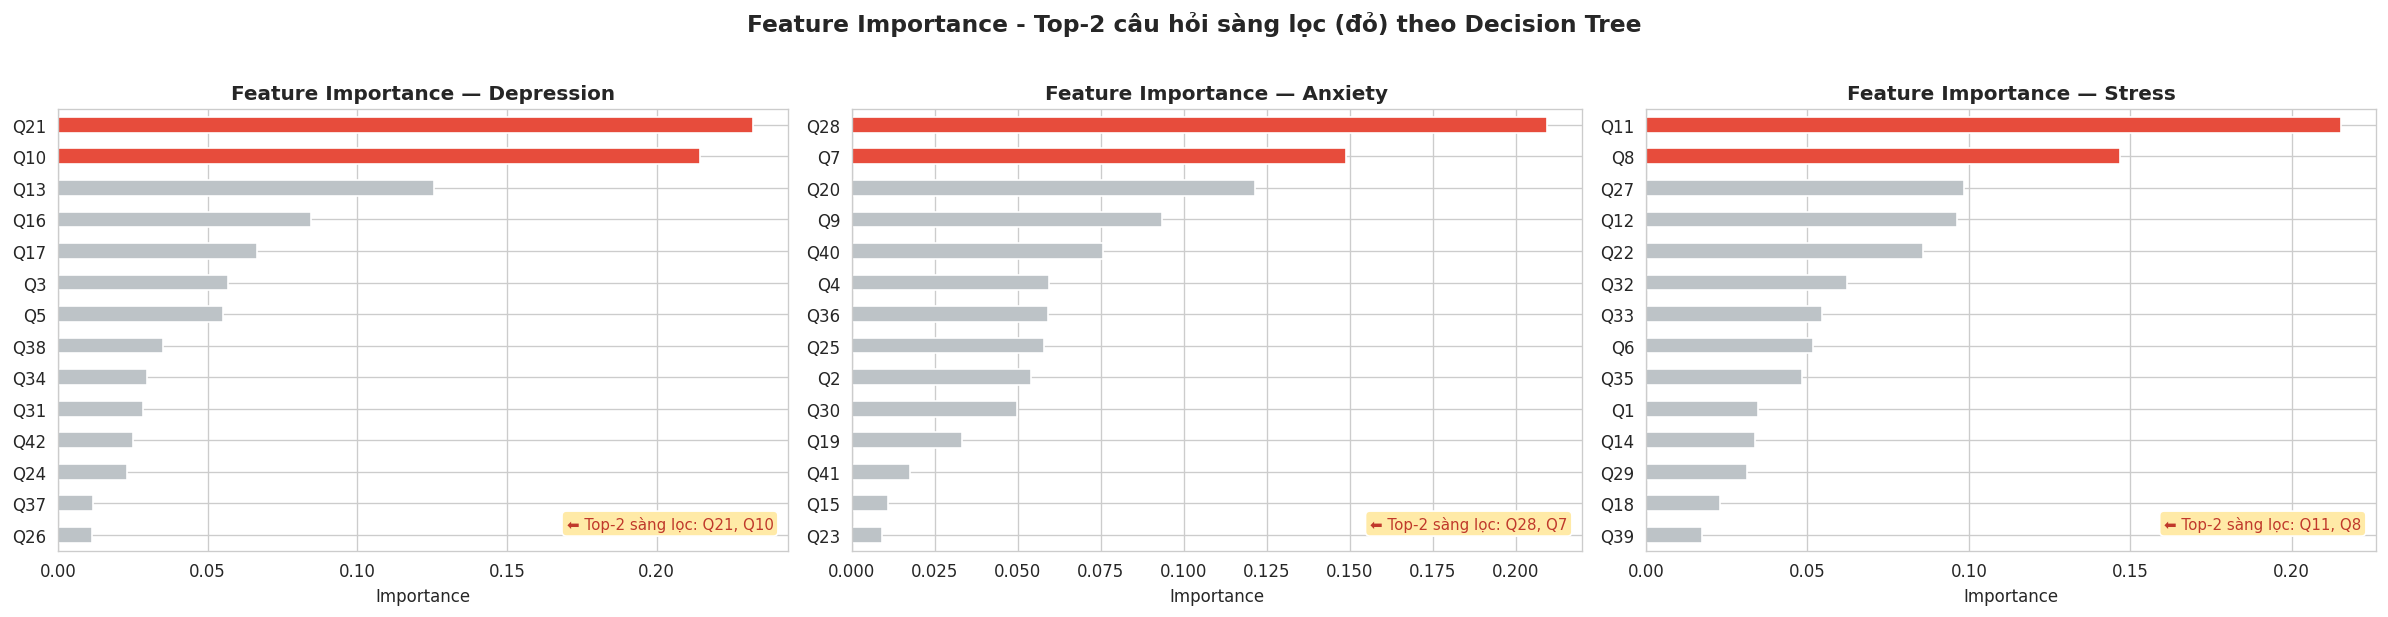

In [10]:
# Visualize Feature Importance
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (group, res) in zip(axes, results.items()):
    imp = pd.Series(res['clf'].feature_importances_,
                    index=[f'Q{q}' for q in res['q_list']]
                    ).sort_values(ascending=True)
    colors = ['#e74c3c' if i >= len(imp)-2 else '#bdc3c7' for i in range(len(imp))]
    imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'Feature Importance — {group}', fontweight='bold')
    ax.set_xlabel('Importance')
    top2_names = [f.replace('A','') for f in res['top2'].index]
    ax.annotate(f'⬅ Top-2 sàng lọc: {", ".join(top2_names)}',
                xy=(0.98, 0.05), xycoords='axes fraction',
                ha='right', fontsize=9, color='#c0392b',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffeaa7'))

plt.suptitle('Feature Importance - Top-2 câu hỏi sàng lọc (đỏ) theo Decision Tree',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

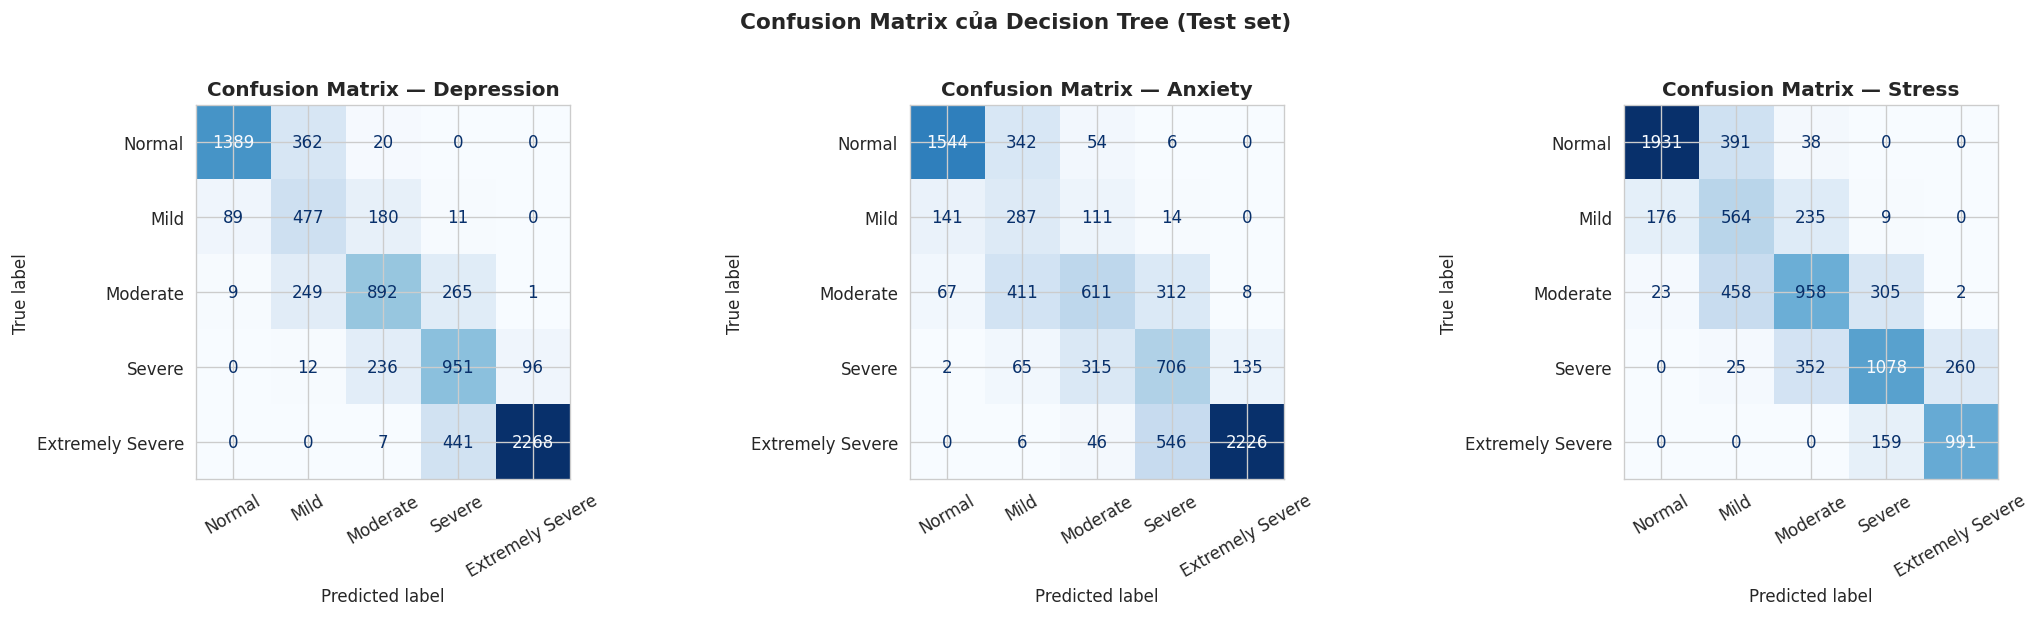

In [11]:
# Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (group, res) in zip(axes, results.items()):
    y_pred = res['clf'].predict(res['X_test'])
    cm     = confusion_matrix(res['y_test'], y_pred)
    present = sorted(res['y_test'].unique())
    names   = [LABEL_NAMES[i] for i in present]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {group}', fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrix của Decision Tree (Test set)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# **PHASE 3: Prolog Knowledge Base**

In [12]:
KB_CONTENT = '''
%% KNOWLEDGE BASE: DASS-42 & M.I.N.I (BACKWARD CHAINING)
%% Tích hợp tiêu chí DSM-5 cho: MDD, GAD, Panic Disorder, Social Anxiety
:- dynamic known/2.

%% Hệ thống đặt câu hỏi (Backward Chaining driver)
  ask_symptom(Question) :- (known(Question, yes)  -> true;
                            known(Question, no)   -> fail;
                            ask_user(Question)
                          ).

ask_user(Question) :- format(atom(Prompt), 'ASK:~w', [Question]),
                      throw(need_input(Prompt)).

ask_symptom_no(Question) :- ( known(Question, no)  -> true;
                              known(Question, yes) -> fail;
                              ask_user(Question), known(Question, no)
                            ).

%% ─── FORWARD CHAINING: Nhận diện Candidate Profile ───
%% Input: D10, A10, S10 = fuzzy_value × 10 (làm tròn)
%% Ưu tiên: maladaptive_crisis > major_depression > panic_disorder > gad_stress_dominant > social_anxiety > low_risk

candidate_profile(maladaptive_crisis, D10, A10, S10) :- D10 >= 30, A10 >= 30, S10 >= 30.

candidate_profile(major_depression, D10, A10, S10) :- D10 >= 25,
                                                   \+ candidate_profile(maladaptive_crisis, D10, A10, S10).

candidate_profile(panic_disorder, D10, A10, S10) :- A10 >= 12, D10 =< 15, S10 =< 20,
                                                 \+ candidate_profile(maladaptive_crisis, D10, A10, S10).

candidate_profile(gad_stress_dominant, D10, A10, S10) :- S10 >= 20, D10 =< 15, A10 =< 15,
                                                      \+ candidate_profile(maladaptive_crisis, D10, A10, S10),
                                                      \+ candidate_profile(panic_disorder, D10, A10, S10).

candidate_profile(social_anxiety, D10, A10, S10) :- A10 >= 10, S10 >= 15,
                                                \+ candidate_profile(panic_disorder, D10, A10, S10),
                                                \+ candidate_profile(major_depression, D10, A10, S10),
                                                \+ candidate_profile(gad_stress_dominant, D10, A10, S10).

candidate_profile(low_risk, D10, A10, S10) :- D10 < 15, A10 < 15, S10 < 15.

%% BACKWARD CHAINING: Xác minh chẩn đoán (DSM-5)

%% MDD — Major Depressive Disorder
%% Tiêu chí DSM-5: ≥1 trong {A1,A2} + ≥4 triệu chứng A3 + A4
ask_a1_or_a2 :- ask_symptom(a1), !.
ask_a1_or_a2 :- ask_symptom(a2).

verify_diagnosis(major_depression) :-
    ask_a1_or_a2,
    ask_symptom(a3),
    ask_symptom(a4).

%% GAD — Generalized Anxiety Disorder
%% Tiêu chí DSM-5: N1(lo lắng quá mức) + ¬N2(không kiểm soát) + N3(≥3 triệu chứng) + N4
verify_diagnosis(gad_stress_dominant) :-
    ask_symptom(n1),
    ask_symptom_no(n2),
    ask_symptom(n3),
    ask_symptom(n4).

%% Panic Disorder
%% Tiêu chí DSM-5: D1a + D1b(đạt đỉnh <10 phút) + D2(bất ngờ) + D4(≥4 triệu chứng soma)
verify_diagnosis(panic_disorder) :-
    ask_symptom(d1a),
    ask_symptom(d1b),
    ask_symptom(d2),
    ask_symptom(d4).

%% Social Anxiety Disorder
%% Tiêu chí DSM-5: F1..F6 tất cả phải đúng
verify_diagnosis(social_anxiety) :-
    ask_symptom(f1),
    ask_symptom(f2),
    ask_symptom(f3),
    ask_symptom(f4),
    ask_symptom(f5),
    ask_symptom(f6).

%% Tự động xác nhận
verify_diagnosis(maladaptive_crisis) :- true.
verify_diagnosis(low_risk)           :- true.

%% Lời khuyên theo Profile
profile_advice(maladaptive_crisis,
    "MUC DO NGUY HIEM: Ban dang kiet suc hoan toan. Lien he ngay bac si tam ly hoac duong day khan cap.").
profile_advice(major_depression,
    "MUC DO NANG (MDD): Duy tri thoi gian bieu co dinh, giu ket noi nguoi than, kham tam ly som.").
profile_advice(panic_disorder,
    "MUC DO NANG (Panic): Tap hit tho sau khi co con, tiep xuc do vat xung quanh, gap chuyen gia.").
profile_advice(gad_stress_dominant,
    "MUC DO VUA-NANG (GAD): Tap keo gian co bap, dat khung gio lo lang co dinh, tu van vien.").
profile_advice(social_anxiety,
    "MUC DO VUA-NANG (SAD): CBT da chung minh hieu qua cao, giup lay lai su tu tin xa hoi.").
profile_advice(low_risk,
    "MUC DO AN TOAN: Khong co dau hieu dang lo ngai. Tiep tuc duy tri loi song lanh manh.").
'''

with open('/content/knowledge_base.pl', 'w', encoding='utf-8') as f:
    f.write(KB_CONTENT)
print(f'   - {KB_CONTENT.count("candidate_profile")} rules Forward Chaining')
print(f'   - {KB_CONTENT.count("verify_diagnosis")} rules Backward Chaining')
print(f'   - {KB_CONTENT.count("profile_advice")} rules lời khuyên')

   - 13 rules Forward Chaining
   - 6 rules Backward Chaining
   - 6 rules lời khuyên


In [13]:
from pyswip import Prolog

prolog = Prolog()
prolog.consult('/content/knowledge_base.pl')

# Test Forward Chaining
print('\n--- Test Forward Chaining (candidate_profile) ---')
test_cases = [
    (35, 35, 35, 'Expect: maladaptive_crisis'),
    (28,  5,  5, 'Expect: major_depression'),
    ( 5, 15,  5, 'Expect: panic_disorder'),
    ( 5,  5, 25, 'Expect: gad_stress_dominant'),
    ( 5,  5,  5, 'Expect: low_risk'),
]
for d, a, s, expected in test_cases:
    res = list(prolog.query(f'candidate_profile(P, {d}, {a}, {s})'))
    profile = str(res[0]['P']) if res else 'none'
    ok = '✅' if expected.split(': ')[1] == profile else '❌'
    print(f'  {ok} D={d:2d} A={a:2d} S={s:2d} → {profile:<22} | {expected}')


--- Test Forward Chaining (candidate_profile) ---
  ✅ D=35 A=35 S=35 → maladaptive_crisis     | Expect: maladaptive_crisis
  ✅ D=28 A= 5 S= 5 → major_depression       | Expect: major_depression
  ✅ D= 5 A=15 S= 5 → panic_disorder         | Expect: panic_disorder
  ✅ D= 5 A= 5 S=25 → gad_stress_dominant    | Expect: gad_stress_dominant
  ✅ D= 5 A= 5 S= 5 → low_risk               | Expect: low_risk


# **PHASE 4: Fuzzy Logic Engine**

**4.1 Tại sao cần Fuzzy Logic?**

**Vấn đề với phân loại ngưỡng cứng (Crisp Thresholding):**

Theo chuẩn DASS-42, Depression ≤13 = Mild, ≥14 = Moderate. Nhưng:
- Người có điểm **13** và người có điểm **14** chênh nhau 1 điểm nhỏ
  lại nhận **kết luận khác nhau hoàn toàn**.
- Ranh giới cứng này không phản ánh đúng bản chất liên tục của sức khỏe tâm thần.

**Fuzzy Logic giải quyết bằng cách:**
- Cho phép một điểm số **thuộc đồng thời nhiều tập mờ** với các mức độ khác nhau.
- Điểm 13 có thể là: μ(Mild)=0.6, μ(Moderate)=0.4 → kết quả cuối là 1.4 (giữa Mild và Moderate).
- Kết quả là một **giá trị liên tục** phản ánh mức độ thực sự của người dùng.


**4.2 Tại sao chọn Gaussian MF thay vì Triangular/Trapezoidal?**

| Tiêu chí | Gaussian | Triangular | Trapezoidal |
|---|---|---|---|
| Hình dạng | Đường cong mượt mà | Đỉnh nhọn, góc cạnh | Có đỉnh bằng (plateau) |
| Phù hợp với | Dữ liệu tâm lý - phân phối tự nhiên | Dữ liệu kỹ thuật đơn giản | Khi có vùng "chắc chắn 100%" |
| Tính liên tục | C∞ - đạo hàm mọi bậc tồn tại | C⁰ - không khả vi tại đỉnh | C⁰ - không khả vi tại góc |
| Cơ sở thống kê | Phân phối chuẩn | Không có | Không có |
| Chuyển tiếp biên | Mượt mà, không đột ngột | Đột ngột tại đỉnh | Đột ngột tại góc |

**Lý do chọn Gaussian:** Dữ liệu DASS-42 có phân phối xấp xỉ chuẩn (skewed right, nhưng chuẩn trong vùng lâm sàng). Gaussian MF mô hình hóa điều này chính xác hơn - μ cao nhất tại trung tâm lâm sàng của mỗi mức, giảm dần về hai phía theo đường cong tự nhiên.

**Công thức Gaussian MF:**

$$\mu(x) = e^{-\frac{(x - \text{mean})^2}{2\sigma^2}}$$

- `mean`: điểm trung tâm của mức độ (lấy từ ngưỡng lâm sàng DASS-42)
- `σ (sigma)`: độ rộng của hàm - kiểm soát mức độ chồng lấp giữa các tập mờ

**4.3 Tại sao dùng COG thay vì BOA để Defuzzification?**

**Giải mờ (Defuzzification)** là bước chuyển từ tập mờ kết hợp sang một giá trị rõ (crisp) duy nhất.

**a. COG - Center of Gravity (Centroid)**

$$z^* = \frac{\sum_{i} \mu_i \cdot c_i}{\sum_{i} \mu_i}$$

Trong đó:
- $\mu_i$: độ thuộc của tập mờ thứ $i$ tại điểm đầu vào
- $c_i$: tâm của tập mờ output thứ $i$ (0, 1, 2, 3, 4)
- $z^*$: giá trị crisp cuối cùng (0–4)

**b. BOA - Bisector of Area**
BOA tìm điểm chia đôi diện tích của vùng mờ kết hợp. Phức tạp hơn, nhạy cảm hơn với hình dạng bất đối xứng.

**c.Tại sao chọn COG?**
1. **Gaussian MF đối xứng** → COG và BOA cho kết quả gần như nhau → không cần độ phức tạp của BOA.
2. **Ý nghĩa trực quan:** COG = mức độ trung bình có trọng số → dễ giải thích với người dùng.
3. **Ổn định tính toán:** Không phụ thuộc vào giải tích số phức tạp.
4. **Chuẩn công nghiệp:** COG là phương pháp defuzzification phổ biến nhất trong các hệ chuyên gia y tế.


**4.4 Xây dựng Fuzzy System**

In [14]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

LABEL_NAMES_VI = ['Bình thường', 'Nhẹ', 'Vừa', 'Nặng', 'Rất Nặng']

# Tham số Gaussian MF  mean lấy từ trung tâm ngưỡng lâm sàng DASS-42
GAUSS_PARAMS = {
    'depression': {
        'means':  [0,  11, 17, 24, 35],
        'sigmas': [7,   3,  3,  3,  7],
        # mean[0]=0: điểm 0 là trung tâm Normal
        # mean[1]=11: giữa khoảng Mild (10-13)
        # mean[2]=17: giữa khoảng Moderate (14-20)
        # mean[3]=24: giữa khoảng Severe (21-27)
        # mean[4]=35: trung tâm Ext.Severe (≥28)
        # sigma nhỏ hơn ở giữa → phân biệt rõ; sigma lớn hơn ở đầu/cuối → mượt biên
    },
    'anxiety': {
        'means':  [0,   8, 12, 17, 31],
        'sigmas': [5, 2.5, 2.5, 3,  6],
    },
    'stress': {
        'means':  [0,  16, 22, 29, 38],
        'sigmas': [7,   3,  3,  3,  6],
    },
}

class DASSFuzzySystem:
    """
    - Input: điểm số 0-42 cho mỗi chiều
    - MF: Gaussian (lý do: phân phối dữ liệu tâm lý xấp xỉ chuẩn)
    - Defuzzification: COG (Centroid, lý do: ổn định + ý nghĩa trực quan)
    - Output: giá trị liên tục 0-4 + nhãn mức độ
    """
    def __init__(self):
        self.systems = {
            name: self._build(name) for name in ['depression', 'anxiety', 'stress']
        }

    def _build(self, name):
        params = GAUSS_PARAMS[name]
        means, sigmas = params['means'], params['sigmas']
        term_names = ['normal', 'mild', 'moderate', 'severe', 'extremely_severe']

        # Biến đầu vào: điểm DASS (0-42)
        score = ctrl.Antecedent(np.arange(0, 43, 1), f'{name}_score')
        # Biến đầu ra: mức độ (0-4, liên tục)
        level = ctrl.Consequent(np.arange(0, 4.1, 0.1), f'{name}_level')

        # Gán Gaussian MF cho đầu vào
        for i, t in enumerate(term_names):
            score[t] = fuzz.gaussmf(score.universe, means[i], sigmas[i])

        # Gán Gaussian MF cho đầu ra (tâm tại 0,1,2,3,4)
        for i, t in enumerate(term_names):
            level[t] = fuzz.gaussmf(level.universe, float(i), 0.5)

        # Luật Fuzzy: IF score IS X THEN level IS X
        rules = [
            ctrl.Rule(score['normal'],           level['normal']),
            ctrl.Rule(score['mild'],             level['mild']),
            ctrl.Rule(score['moderate'],         level['moderate']),
            ctrl.Rule(score['severe'],           level['severe']),
            ctrl.Rule(score['extremely_severe'], level['extremely_severe']),
            # Luật kết hợp cho vùng biên
            ctrl.Rule(score['mild']     & score['moderate'], level['moderate']),
            ctrl.Rule(score['moderate'] & score['severe'],   level['severe']),
            ctrl.Rule(score['severe']   & score['extremely_severe'], level['extremely_severe']),
        ]

        sim = ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules))
        return {'sim': sim, 'score_var': score, 'level_var': level,
                'means': means, 'sigmas': sigmas, 'term_names': term_names}

    def evaluate(self, name, score_val):
        """Đánh giá fuzzy và trả về kết quả đầy đủ."""
        sys_data = self.systems[name]
        sim = sys_data['sim']
        sim.input[f'{name}_score'] = int(score_val)
        sim.compute()
        crisp = float(sim.output[f'{name}_level'])

        label_idx = min(int(crisp + 0.5), 4)  # làm tròn gần nhất
        if   crisp < 0.5: label_idx = 0
        elif crisp < 1.5: label_idx = 1
        elif crisp < 2.5: label_idx = 2
        elif crisp < 3.5: label_idx = 3
        else:             label_idx = 4

        return {
            'score': score_val,
            'fuzzy_value': round(crisp, 4),
            'label_idx': label_idx,
            'label': LABEL_NAMES[label_idx],
        }

fuzzy_doctor = DASSFuzzySystem()
print(f'   Chiều đánh giá: {list(fuzzy_doctor.systems.keys())}')

   Chiều đánh giá: ['depression', 'anxiety', 'stress']


**4.5 Visualization Membership Functions**

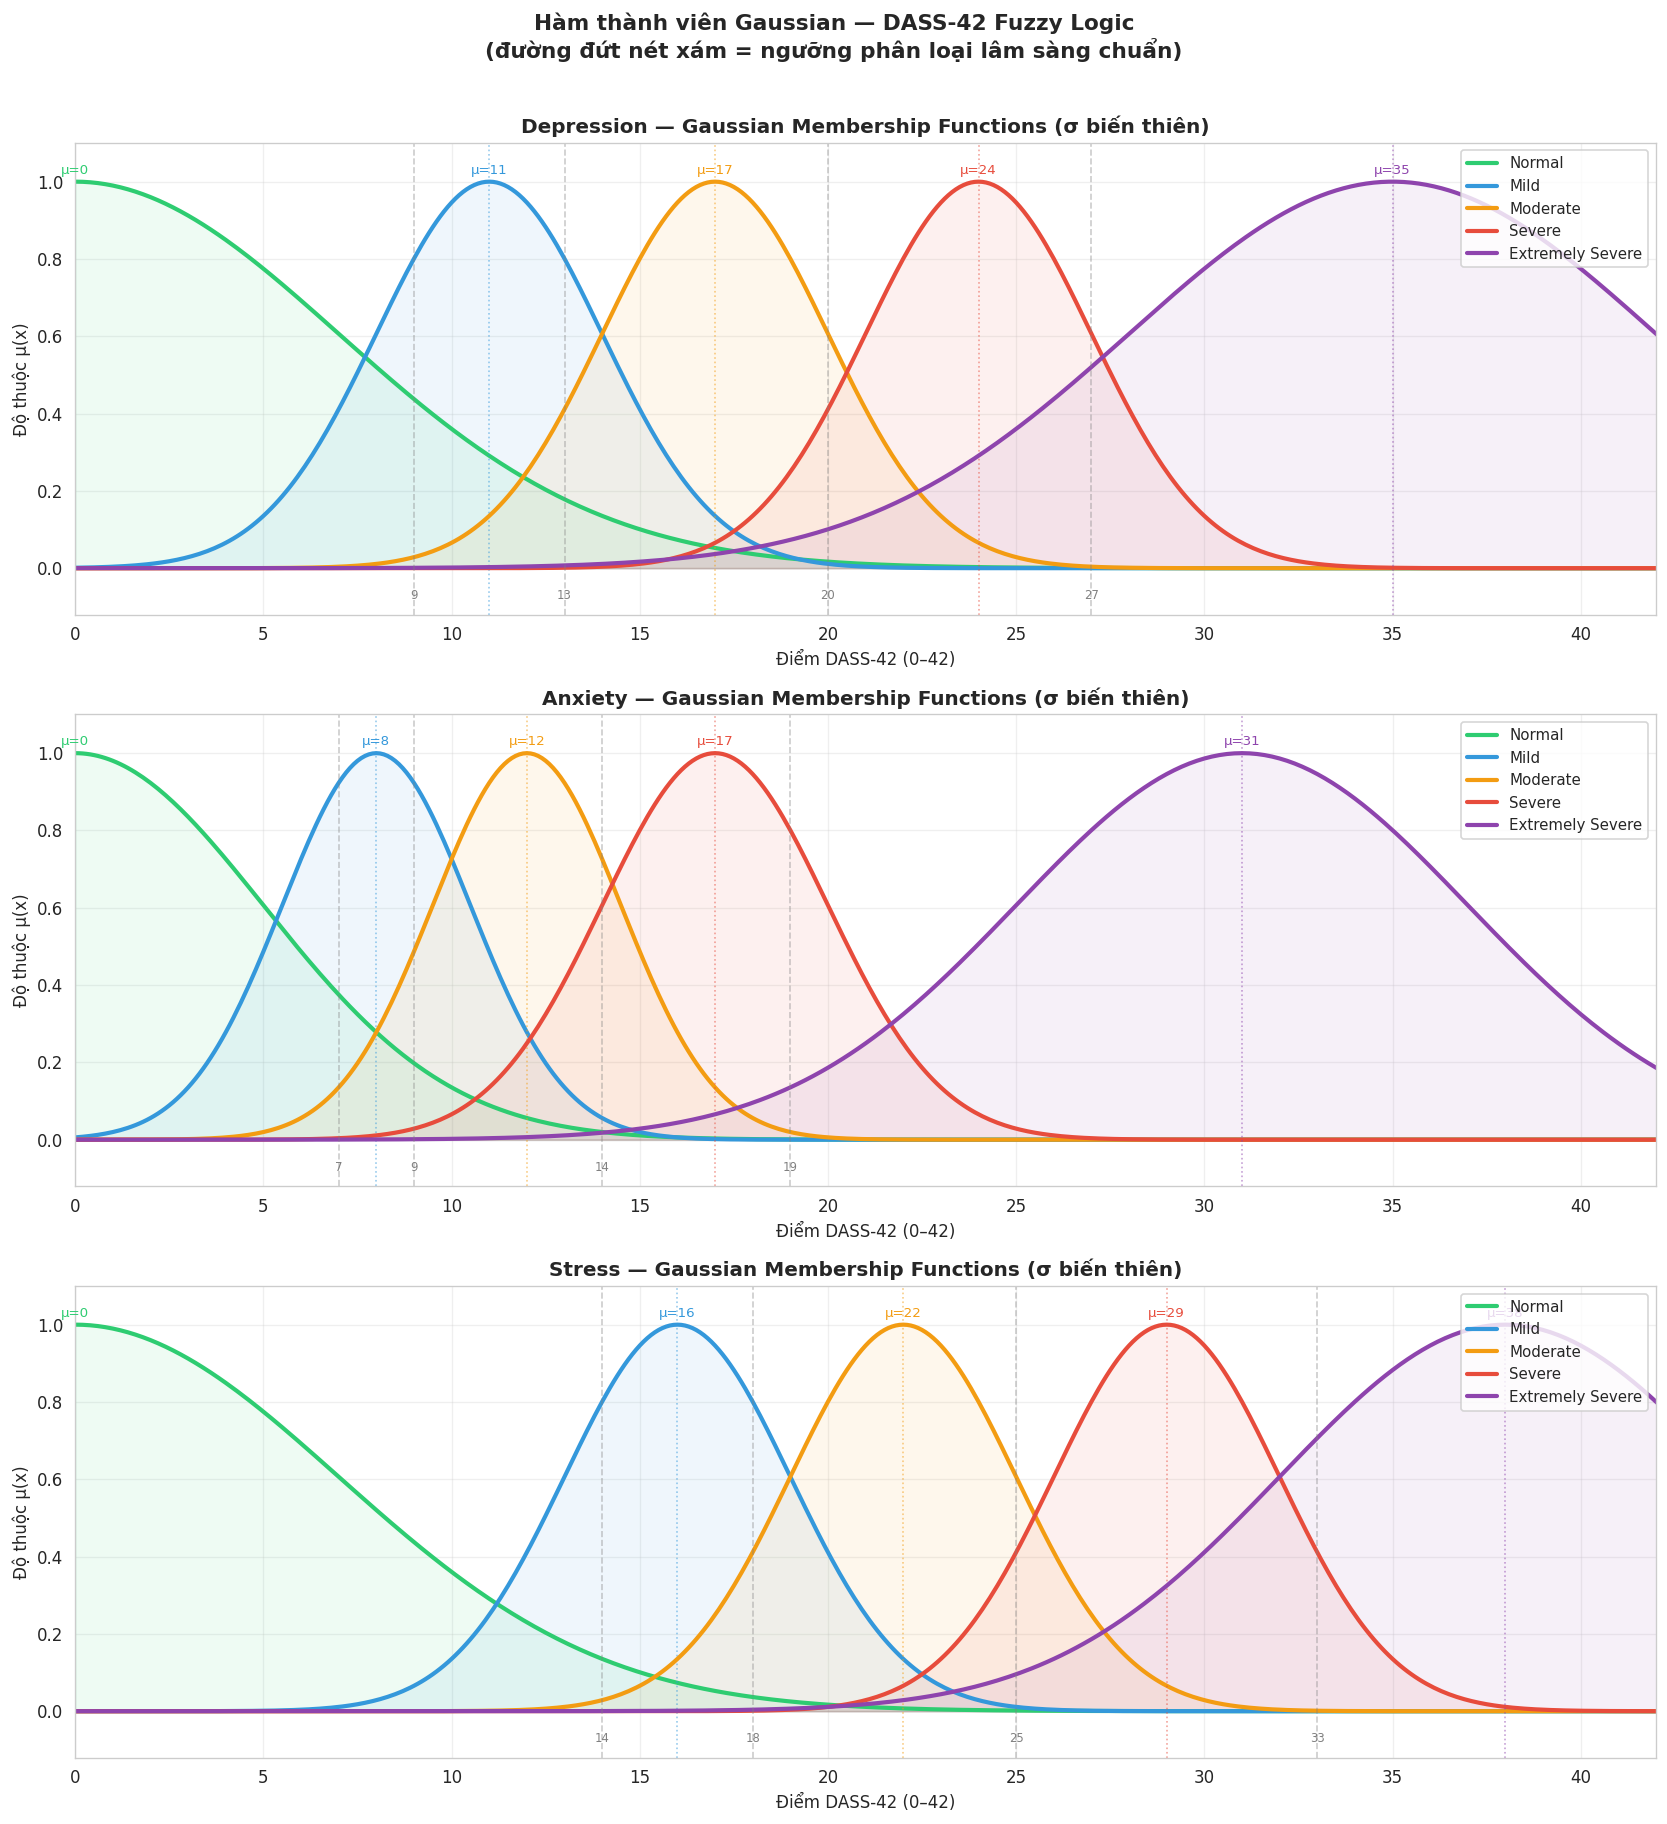

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(14, 15))
term_names = ['normal', 'mild', 'moderate', 'severe', 'extremely_severe']
term_labels = ['Normal', 'Mild', 'Moderate', 'Severe', 'Extremely Severe']

for ax, (name, title) in zip(axes, [
    ('depression', 'Depression'),
    ('anxiety',    'Anxiety'),
    ('stress',     'Stress')
]):
    params = GAUSS_PARAMS[name]
    x = np.arange(0, 43, 0.1)

    for i, (t, label) in enumerate(zip(term_names, term_labels)):
        mu = fuzz.gaussmf(x, params['means'][i], params['sigmas'][i])
        ax.plot(x, mu, color=COLORS_5[i], linewidth=2.5, label=label)
        ax.fill_between(x, mu, alpha=0.08, color=COLORS_5[i])
        # Đánh dấu mean
        ax.axvline(params['means'][i], color=COLORS_5[i], linestyle=':', alpha=0.5, linewidth=1)
        ax.text(params['means'][i], 1.02, f"μ={params['means'][i]}",
                ha='center', fontsize=8, color=COLORS_5[i])

    # Đánh dấu ngưỡng lâm sàng
    thresholds = {'depression': [9,13,20,27], 'anxiety': [7,9,14,19], 'stress': [14,18,25,33]}
    for thr in thresholds[name]:
        ax.axvline(thr, color='gray', linestyle='--', alpha=0.4, linewidth=1)
        ax.text(thr, -0.08, str(thr), ha='center', fontsize=7, color='gray')

    ax.set_title(f'{title} — Gaussian Membership Functions (σ biến thiên)', fontweight='bold', fontsize=12)
    ax.set_xlabel('Điểm DASS-42 (0–42)')
    ax.set_ylabel('Độ thuộc μ(x)')
    ax.legend(loc='upper right', fontsize=9)
    ax.set_xlim(0, 42)
    ax.set_ylim(-0.12, 1.1)
    ax.grid(alpha=0.3)

plt.suptitle('Hàm thành viên Gaussian — DASS-42 Fuzzy Logic\n'
             '(đường đứt nét xám = ngưỡng phân loại lâm sàng chuẩn)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**4.6 Minh họa quá trình COG Defuzzification từng bước**

In [16]:
def demonstrate_cog(name, score_val):
    """Minh họa chi tiết từng bước tính COG Defuzzification."""
    params = GAUSS_PARAMS[name]
    term_names_full = ['normal', 'mild', 'moderate', 'severe', 'extremely_severe']
    term_labels_show = ['Normal', 'Mild', 'Moderate', 'Severe', 'Ext. Severe']
    centers = [0, 1, 2, 3, 4]  # Tâm của output MF

    print(f"\n{'='*68}")
    print(f"  COG DEFUZZIFICATION — {name.upper()} | Điểm đầu vào = {score_val}")
    print(f"{'='*68}")

    # Bước 1: Fuzzification
    print(f"\n  BƯỚC 1 — MỜ HÓA (Fuzzification)")
    print(f"  Áp dụng Gaussian MF: μ(x) = exp(-(x - mean)² / (2σ²))")
    print(f"  {'Tập mờ':<15} | {'mean':>4} | {'σ':>4} | {'Công thức khai triển':<35} | μ")
    print(f"  {'─'*80}")

    memberships = []
    for i, (t, label) in enumerate(zip(term_names_full, term_labels_show)):
        mean  = params['means'][i]
        sigma = params['sigmas'][i]
        mu    = math.exp(-((score_val - mean)**2) / (2 * sigma**2))
        formula = f"exp(-(({score_val}-{mean})²/(2×{sigma}²)))"
        flag  = ' ◄ active' if mu > 0.01 else ''
        print(f"  {label:<15} | {mean:>4} | {sigma:>4} | {formula:<35} | {mu:.4f}{flag}")
        memberships.append((label, mu, centers[i]))

    # Bước 2: Rule activation
    print(f"\n  BƯỚC 2 — KÍCH HOẠT LUẬT (Rule Activation)")
    print(f"  Mỗi luật IF score IS X THEN level IS X → output MF bị cắt tại μ(x)")
    active = [(l, mu, c) for l, mu, c in memberships if mu > 0.01]
    for l, mu, c in active:
        print(f"    IF score IS {l} THEN level IS {l}  →  activation = {mu:.4f}")

    # Bước 3: COG
    print(f"\n  BƯỚC 3 — GIẢI MỜ COG (Center of Gravity)")
    print(f"  Công thức: z* = Σ(μᵢ × cᵢ) / Σ(μᵢ)")
    print(f"  Trong đó cᵢ = tâm output tập mờ thứ i ∈ {{0, 1, 2, 3, 4}}\n")

    num_parts  = [f"({mu:.4f}×{c})" for _, mu, c in memberships]
    num_vals   = [mu * c             for _, mu, c in memberships]
    den_parts  = [f"{mu:.4f}"        for _, mu, _ in memberships]

    numerator   = sum(num_vals)
    denominator = sum(mu for _, mu, _ in memberships)
    crisp       = numerator / denominator if denominator > 0 else 0

    print(f"  Tử số  = {' + '.join(num_parts)}")
    print(f"         = {' + '.join(f'{v:.4f}' for v in num_vals)}")
    print(f"         = {numerator:.4f}")
    print(f"  Mẫu số = {' + '.join(den_parts)}")
    print(f"         = {denominator:.4f}")
    print(f"\n  → z* (COG) = {numerator:.4f} / {denominator:.4f} = {crisp:.4f}")

    label_idx = 0 if crisp < 0.5 else (1 if crisp < 1.5 else (2 if crisp < 2.5 else (3 if crisp < 3.5 else 4)))
    print(f"  → Kết luận: {LABEL_NAMES[label_idx].upper()} (crisp={crisp:.4f} ∈ [{label_idx-0.5:.1f}, {label_idx+0.5:.1f}))")
    print(f"{'='*68}")
    return crisp, label_idx

print('Demo COG Defuzzification với các điểm đặc trưng:\n')
demonstrate_cog('depression', 13)  # Ranh giới Mild/Moderate
demonstrate_cog('depression', 20)  # Ranh giới Moderate/Severe
demonstrate_cog('anxiety', 12)     # Moderate Anxiety

Demo COG Defuzzification với các điểm đặc trưng:


  COG DEFUZZIFICATION — DEPRESSION | Điểm đầu vào = 13

  BƯỚC 1 — MỜ HÓA (Fuzzification)
  Áp dụng Gaussian MF: μ(x) = exp(-(x - mean)² / (2σ²))
  Tập mờ          | mean |    σ | Công thức khai triển                | μ
  ────────────────────────────────────────────────────────────────────────────────
  Normal          |    0 |    7 | exp(-((13-0)²/(2×7²)))              | 0.1783 ◄ active
  Mild            |   11 |    3 | exp(-((13-11)²/(2×3²)))             | 0.8007 ◄ active
  Moderate        |   17 |    3 | exp(-((13-17)²/(2×3²)))             | 0.4111 ◄ active
  Severe          |   24 |    3 | exp(-((13-24)²/(2×3²)))             | 0.0012
  Ext. Severe     |   35 |    7 | exp(-((13-35)²/(2×7²)))             | 0.0072

  BƯỚC 2 — KÍCH HOẠT LUẬT (Rule Activation)
  Mỗi luật IF score IS X THEN level IS X → output MF bị cắt tại μ(x)
    IF score IS Normal THEN level IS Normal  →  activation = 0.1783
    IF score IS Mild THEN level IS Mild  →

(1.9197163496266612, 2)

**4.7 So sánh Fuzzy vs Crisp Thresholding**

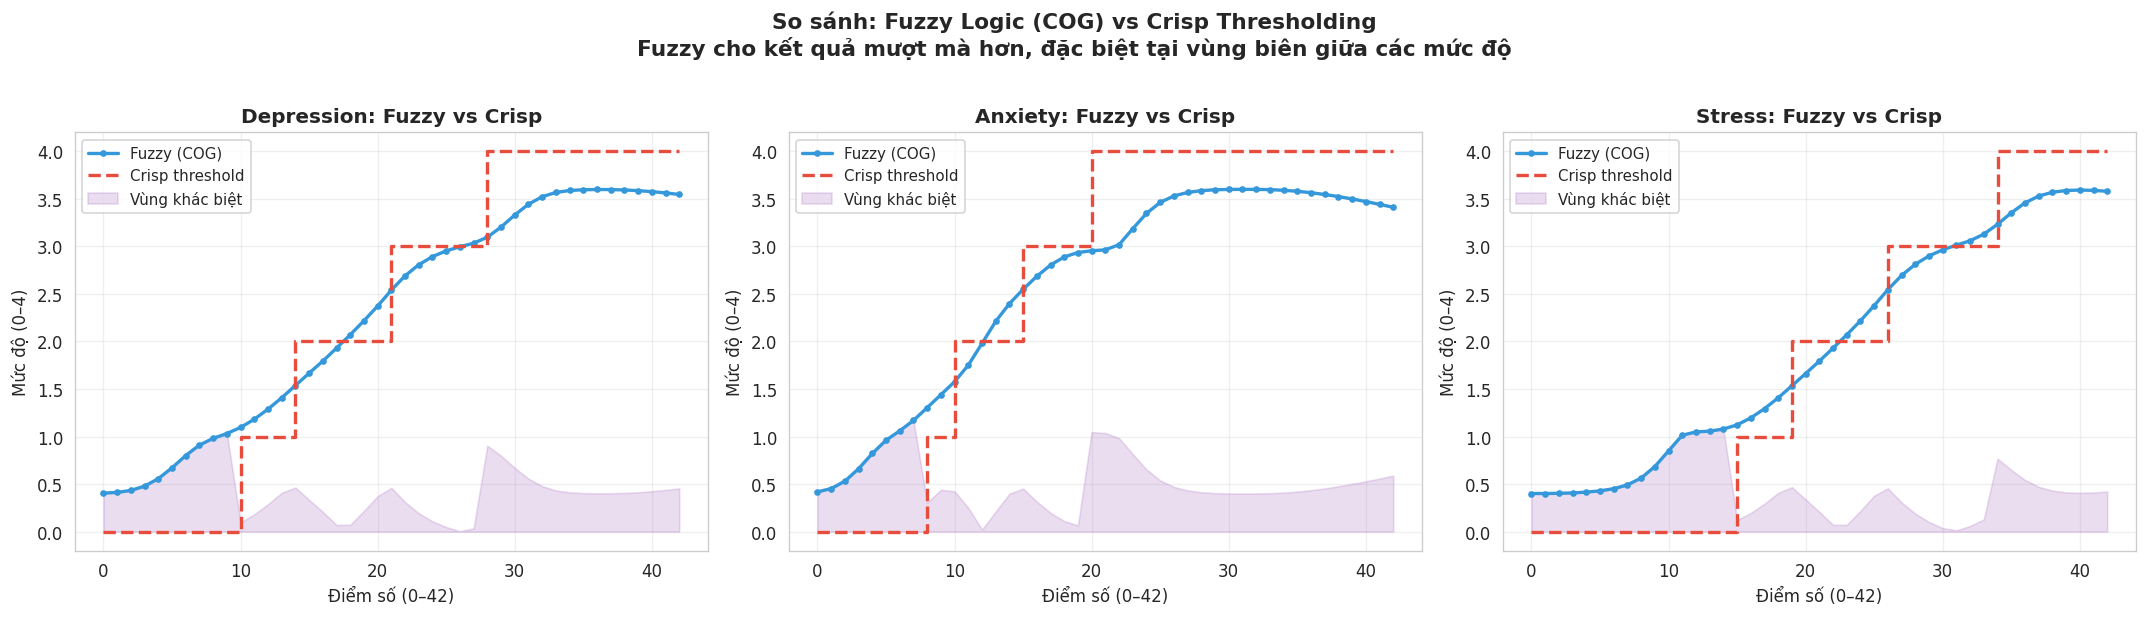

In [17]:
sample_scores = np.arange(0, 43, 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, label_fn, title) in zip(axes, [
    ('depression', label_depression, 'Depression'),
    ('anxiety',    label_anxiety,    'Anxiety'),
    ('stress',     label_stress,     'Stress'),
]):
    fuzzy_vals = [fuzzy_doctor.evaluate(name, s)['fuzzy_value'] for s in sample_scores]
    crisp_vals = [label_fn(s) for s in sample_scores]
    diff_vals  = [abs(f-c) for f,c in zip(fuzzy_vals, crisp_vals)]

    ax.plot(sample_scores, fuzzy_vals, 'o-', color='#3498db',
            label='Fuzzy (COG)', linewidth=2, markersize=3)
    ax.step(sample_scores, crisp_vals, where='post', color='#e74c3c',
            label='Crisp threshold', linewidth=2, linestyle='--')
    ax.fill_between(sample_scores, diff_vals, alpha=0.2, color='#9b59b6',
                    label='Vùng khác biệt')

    ax.set_title(f'{title}: Fuzzy vs Crisp', fontweight='bold')
    ax.set_xlabel('Điểm số (0–42)')
    ax.set_ylabel('Mức độ (0–4)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('So sánh: Fuzzy Logic (COG) vs Crisp Thresholding\n'
             'Fuzzy cho kết quả mượt mà hơn, đặc biệt tại vùng biên giữa các mức độ',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#**PHASE 5: Tích hợp Hệ Chuyên Gia**

**5.1 Tổng quan Pipeline tích hợp**

```
               MINDCOMPASS EXPERT SYSTEM — PIPELINE

 ┌──────────────────────────────────────────────────────────────────┐
 │  INPUT: Câu trả lời DASS-42 (42 câu, mỗi câu 0-3)                │
 └─────────────────────────┬────────────────────────────────────────┘
                           │
                    [BƯỚC 1: Sàng lọc]
           Prolog: screening_dim(q1, q2, Action)
           ├── skip: điểm 2 câu đại diện ≤ ngưỡng → bỏ qua chiều này
           └── ask_more: vượt ngưỡng → hỏi đủ 14 câu
                           │
                    [BƯỚC 2: Tính điểm]
           skip → nội suy từ 2 câu: (q1+q2)/2 × 14
           ask_more → tổng 14 câu thực tế
                           │
                    [BƯỚC 3: Fuzzification]
           μ(x) = exp(-(x-mean)²/(2σ²)) cho 5 tập mờ
                           │
                    [BƯỚC 4: Rule Activation + COG]
           z* = Σ(μᵢ·cᵢ)/Σ(μᵢ) → giá trị liên tục 0-4
                           │
                    [BƯỚC 5: Lời khuyên đơn chiều]
           DIM_ADVICE[dim][label_idx]
                           │
                    [BƯỚC 6: Forward Chaining]
           candidate_profile(Profile, D×10, A×10, S×10)
                           │
                    [BƯỚC 7: Backward Chaining]
           verify_diagnosis(Profile) — hỏi tiêu chí DSM-5
           ├── Đủ tiêu chí → xác nhận profile
           └── Không đủ + fuzzy thấp → fallback low_risk
                           │
 ┌─────────────────────────▼────────────────────────────────────────┐
 │  OUTPUT: Profile + Mức độ 3 chiều + Lời khuyên cá nhân hóa     │
 └──────────────────────────────────────────────────────────────────┘
```

In [18]:
# Cấu hình sàng lọc
SCREENING_CFG = {
    'depression': {'q1': 21, 'q2': 10, 'threshold': 1.5},
    'anxiety':    {'q1': 28, 'q2':  7, 'threshold': 1.5},
    'stress':     {'q1': 11, 'q2':  8, 'threshold': 1.5},
}

DIM_QUESTIONS = {
    'depression': [3, 5, 10, 13, 16, 17, 21, 24, 26, 31, 34, 37, 38, 42],
    'anxiety':    [2, 4,  7,  9, 15, 19, 20, 23, 25, 28, 30, 36, 40, 41],
    'stress':     [1, 6,  8, 11, 12, 14, 18, 22, 27, 29, 32, 33, 35, 39],
}

DIM_ADVICE = {
    'depression': [
        'Trầm cảm: Bạn đang ổn định. Duy trì lối sống lành mạnh nhé!',
        'Trầm cảm: Có dấu hiệu nhẹ. Tập thể dục, ngủ đủ giấc và chia sẻ với người thân.',
        'Trầm cảm: Mức độ vừa. Nên gặp chuyên viên tư vấn để được hỗ trợ.',
        'Trầm cảm: Mức độ nặng. Cần tìm gặp chuyên gia tâm lý càng sớm càng tốt.',
        'Trầm cảm: Rất nặng. Cần can thiệp y tế khẩn cấp, liên hệ bác sĩ ngay.',
    ],
    'anxiety': [
        'Lo âu: Không có dấu hiệu lo âu. Rất tốt!',
        'Lo âu: Hơi lo âu. Thử tập hít thở sâu và thiền định.',
        'Lo âu: Mức độ vừa. Hạn chế caffeine, nghỉ ngơi và thư giãn.',
        'Lo âu: Nặng. Những cơn hoảng loạn có thể xảy ra, cần sự hỗ trợ chuyên gia.',
        'Lo âu: Rất nặng. Tìm kiếm hỗ trợ y tế ngay lập tức.',
    ],
    'stress': [
        'Căng thẳng: Bạn kiểm soát căng thẳng rất tốt!',
        'Căng thẳng: Có chút căng thẳng. Hãy thư giãn và nghỉ ngơi.',
        'Căng thẳng: Vừa. Cần cân bằng lại công việc và cuộc sống.',
        'Căng thẳng: Nặng. Nguy cơ kiệt sức, hãy tạm dừng và gặp chuyên gia.',
        'Căng thẳng: Rất nặng. Đang quá tải nghiêm trọng, cần can thiệp y tế.',
    ],
}

PROFILE_ADVICE = {
    'maladaptive_crisis':  'MỨC ĐỘ NGUY HIỂM: Bạn đang kiệt sức hoàn toàn về mặt tâm lý. Xin đừng cố chịu đựng một mình, hãy liên hệ ngay với bác sĩ tâm lý hoặc đường dây hỗ trợ y tế khẩn cấp.',
    'major_depression':    'MỨC ĐỘ NẶNG (Trầm cảm nặng - MDD): Bạn đang đánh mất năng lượng và niềm vui sống. Hãy duy trì thời gian biểu sinh hoạt cố định, giữ kết nối với người thân và đi khám tâm lý.',
    'panic_disorder':      'MỨC ĐỘ NẶNG (Hoảng sợ cấp tính): Khi cơn hoảng sợ đến, hãy tập hít thở sâu, chạm vào các đồ vật xung quanh để kéo tâm trí về hiện tại. Bạn nên gặp chuyên gia.',
    'gad_stress_dominant': 'MỨC ĐỘ VỪA-NẶNG (Lo âu & Căng thẳng kéo dài - GAD): Hãy thử các bài tập kéo giãn cơ bắp, dành ra một khung giờ lo lắng cố định, và trò chuyện với tư vấn viên.',
    'social_anxiety':      'MỨC ĐỘ VỪA-NẶNG (Lo âu xã hội): Trị liệu hành vi nhận thức (CBT) đã được chứng minh là cực kỳ hiệu quả để giúp bạn lấy lại sự tự tin.',
    'low_risk':            'MỨC ĐỘ AN TOÀN: Không có dấu hiệu nào đáng lo ngại. Sức khỏe tinh thần của bạn hiện tại rất ổn định. Tiếp tục duy trì lối sống lành mạnh nhé!',
}

In [19]:
BACKWARD_FLOW = {
    'major_depression':    ['a1', 'a2', 'a3', 'a4'],
    'gad_stress_dominant': ['n1', 'n2', 'n3', 'n4'],
    'panic_disorder':      ['d1a', 'd1b', 'd2', 'd4'],
    'social_anxiety':      ['f1', 'f2', 'f3', 'f4', 'f5', 'f6'],
    'maladaptive_crisis':  [],
    'low_risk':            [],
}

BACKWARD_QUESTIONS = {
    # MDD
    'a1': {'type': 'yesno',
           'text': 'Bạn có từng cảm thấy trầm cảm, buồn bã hoặc tuyệt vọng gần như cả ngày, '
                   'hầu hết mỗi ngày, trong ít nhất 2 tuần liên tiếp không?'},
    'a2': {'type': 'yesno',
           'text': 'Bạn có từng mất hứng thú hoặc niềm vui với hầu hết mọi thứ bạn từng yêu thích, '
                   'gần như cả ngày, hầu hết mỗi ngày, trong ít nhất 2 tuần không?'},
    'a3': {'type': 'multiselect', 'min_count': 4,
           'text': 'Trong giai đoạn đó, bạn có gặp các triệu chứng nào sau đây không? '
                   '(Chọn tất cả các triệu chứng bạn gặp)',
           'options': [
               'a) Thay đổi cân nặng/ăn uống rõ rệt (>5% trong 1 tháng)',
               'b) Mất ngủ hoặc ngủ quá nhiều gần như mỗi ngày',
               'c) Vận động chậm chạp hoặc bồn chồn rõ đến mức người khác nhận ra',
               'd) Mệt mỏi hoặc mất năng lượng gần như mỗi ngày',
               'e) Cảm thấy vô dụng hoặc tội lỗi quá mức, gần như mỗi ngày',
               'f) Khó tập trung, suy nghĩ hoặc đưa ra quyết định',
               'g) Thường xuyên nghĩ đến cái chết hoặc có ý nghĩ tự tử',
           ]},
    'a4': {'type': 'yesno',
           'text': 'Những triệu chứng này có gây ra khó khăn đáng kể hoặc ảnh hưởng rõ rệt '
                   'đến công việc, học tập, các mối quan hệ hoặc cuộc sống hàng ngày không?'},

    # GAD
    'n1': {'type': 'yesno',
           'text': 'Trong 6 tháng qua, bạn có lo lắng quá mức về nhiều vấn đề khác nhau '
                   '(công việc, gia đình, sức khỏe, tài chính...) hầu hết các ngày không?'},
    'n2': {'type': 'yesno',  # ask_symptom_no → cần trả lời NO
           'text': 'Bạn có THỂ KIỂM SOÁT được những lo lắng đó — tức là có thể dừng lo lắng khi muốn không?\n'
                   '  [Trả lời "no" = không kiểm soát được = đúng tiêu chí GAD]'},
    'n3': {'type': 'multiselect', 'min_count': 3,
           'text': 'Khi lo lắng trong 6 tháng qua, bạn có gặp các triệu chứng nào sau đây không?',
           'options': [
               'a) Bồn chồn, bứt rứt hoặc cảm giác căng thẳng, dễ giật mình',
               'b) Căng cơ bắp',
               'c) Dễ mệt mỏi',
               'd) Khó tập trung hoặc đầu óc trống rỗng',
               'e) Cáu kỉnh, dễ nổi cáu',
               'f) Khó ngủ (khó đi vào giấc, hay thức giữa đêm, hoặc ngủ không sâu)',
           ]},
    'n4': {'type': 'yesno',
           'text': 'Những lo lắng và triệu chứng này có gây ra khó khăn đáng kể trong công việc, '
                   'các mối quan hệ hoặc cuộc sống hàng ngày không?'},

    # Panic Disorder
    'd1a': {'type': 'yesno',
            'text': 'Bạn có từng trải qua những cơn lo âu đột ngột, dữ dội — sợ hãi, khó chịu '
                    'mà người khác sẽ không cảm thấy như vậy trong tình huống đó — xảy ra nhiều lần không?'},
    'd1b': {'type': 'yesno',
            'text': 'Những cơn đó có đạt đến đỉnh điểm trong vòng 10 phút kể từ khi bắt đầu không?'},
    'd2':  {'type': 'yesno',
            'text': 'Có ít nhất một cơn xuất hiện hoàn toàn bất ngờ, không có nguyên nhân hay '
                    'tình huống kích hoạt rõ ràng không?'},
    'd4':  {'type': 'multiselect', 'min_count': 4,
            'text': 'Trong cơn tệ nhất bạn từng trải qua, bạn có gặp các triệu chứng nào sau đây?',
            'options': [
                'a) Tim đập nhanh, mạnh hoặc loạn nhịp',
                'b) Đổ mồ hôi hoặc bàn tay ẩm',
                'c) Run rẩy hoặc lắc',
                'd) Khó thở, thở gấp hoặc cảm giác bị nghẹt thở',
                'e) Cảm giác bị nghẹn ở cổ họng',
                'f) Đau ngực, tức ngực hoặc khó chịu ở ngực',
                'g) Buồn nôn, đau bụng hoặc tiêu chảy đột ngột',
                'h) Chóng mặt, loạng choạng, nhẹ đầu hoặc sắp ngất',
                'i) Người nóng bừng hoặc ớn lạnh',
                'j) Tê bì hoặc ngứa ran ở các bộ phận cơ thể',
                'k) Mọi thứ xung quanh trông lạ lẫm hoặc cảm thấy tách rời khỏi bản thân',
                'l) Sợ mất kiểm soát hoặc sắp hóa điên',
                'm) Sợ chết',
            ]},

    # Social Anxiety
    'f1': {'type': 'yesno',
           'text': 'Bạn có cảm thấy sợ hãi rõ rệt khi bị người khác nhìn, trở thành tâm điểm, '
                   'hoặc sợ bị xấu hổ trong các tình huống xã hội không? (nói nhóm, gặp người mới...)'},
    'f2': {'type': 'yesno',
           'text': 'Các tình huống xã hội đó hầu như LUÔN gây ra nỗi sợ hoặc lo âu cho bạn không?'},
    'f3': {'type': 'yesno',
           'text': 'Bạn có NÉ TRÁNH các tình huống xã hội đó, hoặc phải chịu đựng chúng '
                   'với cảm giác rất khó chịu không?'},
    'f4': {'type': 'yesno',
           'text': 'Nỗi sợ này có vẻ QUÁ MỨC so với mức độ nguy hiểm thực sự của tình huống không?'},
    'f5': {'type': 'yesno',
           'text': 'Tình trạng này đã kéo dài ít nhất 6 THÁNG không?'},
    'f6': {'type': 'yesno',
           'text': 'Những nỗi sợ này có gây ra khó khăn đáng kể hoặc ảnh hưởng rõ rệt '
                   'đến công việc, học tập hoặc các mối quan hệ của bạn không?'},
}

for profile, flow in BACKWARD_FLOW.items():
    if flow:
        print(f'  {profile}: {len(flow)} câu hỏi → {flow}')
    else:
        print(f'  {profile}: tự động xác nhận (không cần hỏi)')

  major_depression: 4 câu hỏi → ['a1', 'a2', 'a3', 'a4']
  gad_stress_dominant: 4 câu hỏi → ['n1', 'n2', 'n3', 'n4']
  panic_disorder: 4 câu hỏi → ['d1a', 'd1b', 'd2', 'd4']
  social_anxiety: 6 câu hỏi → ['f1', 'f2', 'f3', 'f4', 'f5', 'f6']
  maladaptive_crisis: tự động xác nhận (không cần hỏi)
  low_risk: tự động xác nhận (không cần hỏi)


In [20]:
def run_expert_system(answers: dict, verbose=True) -> dict:
    LINE = lambda c='-', n=70: c*n
    get  = lambda q: answers.get(q, 0)

    final = {}

    if verbose:
        print(LINE('='))
        print(f"{'HỆ CHUYÊN GIA MINDCOMPASS — DASS-42':^70}")
        print(LINE('='))

    dim_label_map = {
        'depression': 'TRẦM CẢM (Depression)',
        'anxiety':    'LO ÂU (Anxiety)',
        'stress':     'CĂNG THẲNG (Stress)',
    }

    for dim in ['depression', 'anxiety', 'stress']:
        cfg   = SCREENING_CFG[dim]
        q1, q2, thr = cfg['q1'], cfg['q2'], cfg['threshold']
        v1, v2 = get(q1), get(q2)
        all_qs = DIM_QUESTIONS[dim]

        if verbose:
            print(f"\n[{dim_label_map[dim]}]")
            print(LINE())

        # BƯỚC 1: Sàng lọc
        if v1 <= thr and v2 <= thr:
            action = 'skip'
            reason = f'Rủi ro thấp: Q{q1}={v1} và Q{q2}={v2} đều ≤ {thr}'
        else:
            action = 'ask_more'
            reason = f'Cần đánh giá thêm: Q{q1}={v1} hoặc Q{q2}={v2} vượt ngưỡng'

        if verbose:
            print(f" BƯỚC 1: SÀNG LỌC NHANH")
            print(f"   Q{q1}={v1}  Q{q2}={v2}  ngưỡng={thr}  → {action.upper()}")
            print(f"   {reason}")

        if action == 'skip':
            if verbose: print(f"   → Bỏ qua — rủi ro thấp.\n")
            final[dim] = {'screening_action': 'skip', 'total_score': 0,
                          'fuzzy_value': 0.0, 'label_idx': 0, 'label': 'Normal',
                          'advice': DIM_ADVICE[dim][0]}
            continue

        # BƯỚC 2: Tính điểm
        detail   = {q: get(q) for q in all_qs}
        total    = sum(detail.values())
        method   = 'Tổng 14 câu đầy đủ'

        if verbose:
            print(f"\n BƯỚC 2: TÍNH ĐIỂM TỔNG")
            print(f"   Phương pháp: {method}")
            items = [f"Q{q}={v}" for q, v in detail.items()]
            for i in range(0, len(items), 7):
                prefix = '   Chi tiết : ' if i == 0 else '               '
                print(prefix + '  '.join(items[i:i+7]))
            print(f"   → ĐIỂM TỔNG: {total} / 42")

        # BƯỚC 3 & 4: Fuzzy
        fuzzy_res = fuzzy_doctor.evaluate(dim, total)
        crisp     = fuzzy_res['fuzzy_value']
        label_idx = fuzzy_res['label_idx']

        # Tính μ thủ công để hiển thị
        params = GAUSS_PARAMS[dim]
        terms  = ['Normal','Mild','Moderate','Severe','Ext.Severe']
        mus    = [math.exp(-((total-m)**2)/(2*s**2))
                  for m, s in zip(params['means'], params['sigmas'])]

        if verbose:
            print(f"\n BƯỚC 3: FUZZIFICATION (Gaussian MF)")
            print(f"   {'Tập mờ':<14} | {'mean':>4} | {'σ':>4} | μ(x)")
            for t, m, s, mu in zip(terms, params['means'], params['sigmas'], mus):
                flag = ' ◄' if mu > 0.01 else ''
                print(f"   {t:<14} | {m:>4} | {s:>4} | {mu:.4f}{flag}")

            print(f"\n BƯỚC 4: DEFUZZIFICATION — COG")
            num_parts = [f'({mu:.3f}×{c})' for mu, c in zip(mus, range(5))]
            num_val   = sum(mu*c for mu, c in zip(mus, range(5)))
            den_val   = sum(mus)
            print(f"   z* = ({' + '.join(num_parts)}) / ({' + '.join(f'{mu:.3f}' for mu in mus)})")
            print(f"      = {num_val:.4f} / {den_val:.4f} = {crisp:.4f}")
            print(f"   → Kết luận: {LABEL_NAMES[label_idx].upper()}")

        # BƯỚC 5: Lời khuyên
        advice = DIM_ADVICE[dim][label_idx]
        if verbose:
            print(f"\n BƯỚC 5: LỜI KHUYÊN ĐƠN CHIỀU")
            print(f"   {advice}")

        final[dim] = {
            'screening_action': action, 'total_score': total,
            'fuzzy_value': crisp, 'label_idx': label_idx,
            'label': LABEL_NAMES[label_idx], 'advice': advice,
        }

    # BƯỚC 6: Forward Chaining
    d10 = round(final['depression']['fuzzy_value'] * 10)
    a10 = round(final['anxiety']['fuzzy_value'] * 10)
    s10 = round(final['stress']['fuzzy_value'] * 10)

    fc_res = list(prolog.query(f'candidate_profile(P, {d10}, {a10}, {s10})'))
    profile = str(fc_res[0]['P']) if fc_res else 'low_risk'

    if verbose:
        print(f"\n{LINE('=')}")
        print(f" BƯỚC 6: FORWARD CHAINING")
        print(f"   Fuzzy ×10 → D={d10}  A={a10}  S={s10}")
        print(f"   → Hồ sơ nhận diện: {profile.upper()}")

    # BƯỚC 7: Backward Chaining
    bw_flow = BACKWARD_FLOW.get(profile, [])
    verified = True
    confirm_log = []

    if bw_flow and verbose:
        print(f"\n{LINE('=')}")
        print(f" BƯỚC 7: BACKWARD CHAINING — Xác minh DSM-5")
        print(f" Profile nghi ngờ: {profile.upper()}")
        print(f" Hệ thống sẽ hỏi {len(bw_flow)} câu để xác minh tiêu chí lâm sàng.\n")

    if bw_flow:
        known_answers = {}
        score = 0

        while True:
            try:
                # Thử verify_diagnosis
                list(prolog.query('retractall(known(_,_))'))
                for k, v in known_answers.items():
                    prolog.assertz(f"known({k}, '{v}')")
                result = list(prolog.query(f'verify_diagnosis({profile})'))
                verified = len(result) > 0
                break
            except Exception as e:
                err = str(e)
                if 'need_input' not in err:
                    verified = False
                    break

                match = re.search(r'ASK:(\w+)', err)
                if not match:
                    verified = False
                    break
                q_key = match.group(1)

                q_info = BACKWARD_QUESTIONS.get(q_key, {})
                q_type = q_info.get('type', 'yesno')
                q_text = q_info.get('text', q_key)

                print(f"  {'─'*65}")
                if q_type == 'multiselect':
                    print(f"  [{q_key.upper()}] {q_text}")
                    options = q_info.get('options', [])
                    for i, opt in enumerate(options, 1):
                        print(f"     {i}. {opt}")
                    min_c = q_info.get('min_count', 1)
                    print(f"  (Cần chọn ít nhất {min_c} triệu chứng để đủ tiêu chí)")

                    while True:
                        raw = input(f"  Nhập số thứ tự các triệu chứng bạn gặp (VD: 1,3,5 hoặc để trống nếu không có): ").strip()
                        try:
                            if raw == '':
                                selected_nums = []
                            else:
                                selected_nums = [int(x.strip()) for x in raw.split(',') if x.strip()]
                                assert all(1 <= n <= len(options) for n in selected_nums)
                            break
                        except:
                            print(f"  Nhập số 1-{len(options)}, phân cách bởi dấu phẩy.")

                    selected_count = len(selected_nums)
                    ans = 'yes' if selected_count >= min_c else 'no'
                    mark = '✓' if ans == 'yes' else '✗'
                    print(f"  [{mark}] Đã chọn {selected_count}/{len(options)} triệu chứng (cần ≥{min_c}) → {ans.upper()}")
                    confirm_log.append((q_key, f'{selected_count} triệu chứng', ans))
                    if ans == 'yes': score += 1

                else:  # yesno
                    print(f"  [{q_key.upper()}] {q_text}")
                    while True:
                        ans = input(f"  Trả lời (yes/no): ").strip().lower()
                        if ans in ('yes', 'no'): break
                        print("  Chỉ nhập 'yes' hoặc 'no'.")

                    mark = '✓' if ans == 'yes' else '✗'
                    print(f"  [{mark}] {q_key}: {ans.upper()}")
                    confirm_log.append((q_key, q_text[:60]+'...', ans))
                    if ans == 'yes': score += 1

                known_answers[q_key] = ans

        # Safety net: nếu không verify nhưng fuzzy cao → giữ profile
        if not verified:
            any_severe = any(final.get(d, {}).get('label_idx', 0) >= 3
                             for d in ['depression','anxiety','stress'])
            if not any_severe:
                profile = 'low_risk'
                if verbose: print('\n   → Safety net: không đủ tiêu chí + điểm thấp → LOW_RISK')
            else:
                if verbose: print('\n   → Safety net: điểm fuzzy cao (≥Severe) → giữ profile')

        list(prolog.query('retractall(known(_,_))'))

    # ── Tổng kết ──
    profile_adv = PROFILE_ADVICE.get(profile, PROFILE_ADVICE['low_risk'])

    if verbose:
        print(f"\n{LINE('=')}")
        print(f"{'TỔNG KẾT CHẨN ĐOÁN':^70}")
        print(LINE('='))
        print(f"  {'Chiều':<24} | {'Điểm':^6} | {'Fuzzy':^7} | Kết luận")
        print(LINE('-'))
        for dim, dlabel in dim_label_map.items():
            r = final[dim]
            print(f"  {dlabel:<24} | {r['total_score']:>3}/42 | {r['fuzzy_value']:.3f}  | {r['label'].upper()}")
        print(f"\n  → Profile cuối    : {profile.upper()}")
        print(f"  → Xác nhận DSM-5  : {'ĐÃ XÁC NHẬN ✓' if verified else 'SAFETY NET ⚠'}")
        print(f"\n[KẾT LUẬN] {profile_adv}")
        print(LINE('='))

    final['profile'] = profile
    final['profile_verified'] = verified
    final['profile_advice']   = profile_adv
    return final

**Test Case 1:** Major Depression (MDD)

In [21]:
print('TEST CASE 1: Major Depressive Disorder (MDD)')
print('Mô tả: D cực nặng, A & S thấp → kỳ vọng profile major_depression')
print('Backward Chaining sẽ hỏi: A1/A2 → A3 (multiselect ≥4) → A4\n')

answers_mdd = {q: 0 for q in range(1, 43)}
# Depression nặng
for q in [3,5,10,13,16,17,21,24,26,31,34,37,38,42]:
    answers_mdd[q] = 3
# Anxiety & Stress thấp
for q in [2,4,7,9,15,19,20,23,25,28,30,36,40,41]:
    answers_mdd[q] = 1

result_mdd = run_expert_system(answers_mdd, verbose=True)

TEST CASE 1: Major Depressive Disorder (MDD)
Mô tả: D cực nặng, A & S thấp → kỳ vọng profile major_depression
Backward Chaining sẽ hỏi: A1/A2 → A3 (multiselect ≥4) → A4

                 HỆ CHUYÊN GIA MINDCOMPASS — DASS-42                  

[TRẦM CẢM (Depression)]
----------------------------------------------------------------------
 BƯỚC 1: SÀNG LỌC NHANH
   Q21=3  Q10=3  ngưỡng=1.5  → ASK_MORE
   Cần đánh giá thêm: Q21=3 hoặc Q10=3 vượt ngưỡng

 BƯỚC 2: TÍNH ĐIỂM TỔNG
   Phương pháp: Tổng 14 câu đầy đủ
   Chi tiết : Q3=3  Q5=3  Q10=3  Q13=3  Q16=3  Q17=3  Q21=3
               Q24=3  Q26=3  Q31=3  Q34=3  Q37=3  Q38=3  Q42=3
   → ĐIỂM TỔNG: 42 / 42

 BƯỚC 3: FUZZIFICATION (Gaussian MF)
   Tập mờ         | mean |    σ | μ(x)
   Normal         |    0 |    7 | 0.0000
   Mild           |   11 |    3 | 0.0000
   Moderate       |   17 |    3 | 0.0000
   Severe         |   24 |    3 | 0.0000
   Ext.Severe     |   35 |    7 | 0.6065 ◄

 BƯỚC 4: DEFUZZIFICATION — COG
   z* = ((0.000×0) + (0.0

**Test Case 2:** GAD / Stress Dominant

In [22]:
print('TEST CASE 2: Generalized Anxiety Disorder / Stress Dominant')
print('Mô tả: S nặng, D & A thấp → kỳ vọng profile gad_stress_dominant')
print('Backward Chaining sẽ hỏi: N1 → N2(cần no) → N3(multiselect ≥3) → N4\n')

answers_gad = {q: 0 for q in range(1, 43)}
for q in [1,6,8,11,12,14,18,22,27,29,32,33,35,39]:  # Stress nặng
    answers_gad[q] = 3
for q in [2,4,7,9,15,19,20,23,25,28,30,36,40,41]:   # Anxiety nhẹ
    answers_gad[q] = 1

result_gad = run_expert_system(answers_gad, verbose=True)

TEST CASE 2: Generalized Anxiety Disorder / Stress Dominant
Mô tả: S nặng, D & A thấp → kỳ vọng profile gad_stress_dominant
Backward Chaining sẽ hỏi: N1 → N2(cần no) → N3(multiselect ≥3) → N4

                 HỆ CHUYÊN GIA MINDCOMPASS — DASS-42                  

[TRẦM CẢM (Depression)]
----------------------------------------------------------------------
 BƯỚC 1: SÀNG LỌC NHANH
   Q21=0  Q10=0  ngưỡng=1.5  → SKIP
   Rủi ro thấp: Q21=0 và Q10=0 đều ≤ 1.5
   → Bỏ qua — rủi ro thấp.


[LO ÂU (Anxiety)]
----------------------------------------------------------------------
 BƯỚC 1: SÀNG LỌC NHANH
   Q28=1  Q7=1  ngưỡng=1.5  → SKIP
   Rủi ro thấp: Q28=1 và Q7=1 đều ≤ 1.5
   → Bỏ qua — rủi ro thấp.


[CĂNG THẲNG (Stress)]
----------------------------------------------------------------------
 BƯỚC 1: SÀNG LỌC NHANH
   Q11=3  Q8=3  ngưỡng=1.5  → ASK_MORE
   Cần đánh giá thêm: Q11=3 hoặc Q8=3 vượt ngưỡng

 BƯỚC 2: TÍNH ĐIỂM TỔNG
   Phương pháp: Tổng 14 câu đầy đủ
   Chi tiết : Q1=3  Q6=3  Q

**Test Case 3:** Panic Disorder

In [23]:
print('TEST CASE 3: Panic Disorder')
print('Mô tả: A nặng, D thấp, S thấp → kỳ vọng profile panic_disorder')
print('Backward Chaining sẽ hỏi: D1a → D1b → D2 → D4(multiselect ≥4)\n')

answers_panic = {q: 0 for q in range(1, 43)}
for q in [2,4,7,9,15,19,20,23,25,28,30,36,40,41]:  # Anxiety nặng
    answers_panic[q] = 3
for q in [3,5,10,13,16,17,21,24,26,31,34,37,38,42]: # Depression thấp
    answers_panic[q] = 0

result_panic = run_expert_system(answers_panic, verbose=True)

TEST CASE 3: Panic Disorder
Mô tả: A nặng, D thấp, S thấp → kỳ vọng profile panic_disorder
Backward Chaining sẽ hỏi: D1a → D1b → D2 → D4(multiselect ≥4)

                 HỆ CHUYÊN GIA MINDCOMPASS — DASS-42                  

[TRẦM CẢM (Depression)]
----------------------------------------------------------------------
 BƯỚC 1: SÀNG LỌC NHANH
   Q21=0  Q10=0  ngưỡng=1.5  → SKIP
   Rủi ro thấp: Q21=0 và Q10=0 đều ≤ 1.5
   → Bỏ qua — rủi ro thấp.


[LO ÂU (Anxiety)]
----------------------------------------------------------------------
 BƯỚC 1: SÀNG LỌC NHANH
   Q28=3  Q7=3  ngưỡng=1.5  → ASK_MORE
   Cần đánh giá thêm: Q28=3 hoặc Q7=3 vượt ngưỡng

 BƯỚC 2: TÍNH ĐIỂM TỔNG
   Phương pháp: Tổng 14 câu đầy đủ
   Chi tiết : Q2=3  Q4=3  Q7=3  Q9=3  Q15=3  Q19=3  Q20=3
               Q23=3  Q25=3  Q28=3  Q30=3  Q36=3  Q40=3  Q41=3
   → ĐIỂM TỔNG: 42 / 42

 BƯỚC 3: FUZZIFICATION (Gaussian MF)
   Tập mờ         | mean |    σ | μ(x)
   Normal         |    0 |    5 | 0.0000
   Mild           |    8

**Test Case 4:** Low Risk (Bình thường)

In [24]:
print('TEST CASE 4: Low Risk')
print('Mô tả: Tất cả điểm thấp → kỳ vọng profile low_risk (tự động xác nhận)\n')

answers_low = {q: 0 for q in range(1, 43)}
result_low = run_expert_system(answers_low, verbose=True)

TEST CASE 4: Low Risk
Mô tả: Tất cả điểm thấp → kỳ vọng profile low_risk (tự động xác nhận)

                 HỆ CHUYÊN GIA MINDCOMPASS — DASS-42                  

[TRẦM CẢM (Depression)]
----------------------------------------------------------------------
 BƯỚC 1: SÀNG LỌC NHANH
   Q21=0  Q10=0  ngưỡng=1.5  → SKIP
   Rủi ro thấp: Q21=0 và Q10=0 đều ≤ 1.5
   → Bỏ qua — rủi ro thấp.


[LO ÂU (Anxiety)]
----------------------------------------------------------------------
 BƯỚC 1: SÀNG LỌC NHANH
   Q28=0  Q7=0  ngưỡng=1.5  → SKIP
   Rủi ro thấp: Q28=0 và Q7=0 đều ≤ 1.5
   → Bỏ qua — rủi ro thấp.


[CĂNG THẲNG (Stress)]
----------------------------------------------------------------------
 BƯỚC 1: SÀNG LỌC NHANH
   Q11=0  Q8=0  ngưỡng=1.5  → SKIP
   Rủi ro thấp: Q11=0 và Q8=0 đều ≤ 1.5
   → Bỏ qua — rủi ro thấp.


 BƯỚC 6: FORWARD CHAINING
   Fuzzy ×10 → D=0  A=0  S=0
   → Hồ sơ nhận diện: LOW_RISK

                          TỔNG KẾT CHẨN ĐOÁN                          
  Chiều       